# 🛍️ Système de Recommandation H&M avec LightFM

## Date : 30 octobre 2025

## Objectif du Projet
Développer un système de recommandation complet pour le commerce électronique de mode en utilisant le dataset H&M et la bibliothèque LightFM. Ce projet implémente un pipeline end-to-end allant de l'exploration des données jusqu'au déploiement d'un modèle hybride combinant filtrage collaboratif et métadonnées d'articles.

## Approche Technique
- **Filtrage Collaboratif** : Analyse des interactions utilisateur-article
- **Modèle Hybride** : Intégration des métadonnées (catégories, âge, couleur)
- **Optimisation** : Recherche en grille des hyperparamètres
- **Évaluation** : Métriques AUC, Precision@K, Recall@K

## Consignes du Projet
[Consignes détaillées](https://docs.google.com/document/d/16ZCFuI9-aKwK2FuTMmAgbsrI7gbMFuswlYlmFF2MnkU/edit?usp=drive_link)

## 📋 Table des Matières

### **1. Configuration de l'Environnement**
- Installation des dépendances et imports
- Chargement des données H&M

### **2. Fonctions Utilitaires**
- Fonctions réutilisables pour le pipeline

### **3. Exploration des Données**
- Analyse de la sparsité et des distributions
- Identification des patterns utilisateur-article

### **4. Stratégie d'Échantillonnage**
- Création d'échantillons représentatifs
- Filtrage des utilisateurs et articles actifs

### **5. Pipeline Principal**
- Prétraitement et construction des matrices
- Entraînement des modèles CF et hybrides
- Optimisation des hyperparamètres

### **6. Analyse Comparative**
- Comparaison des performances
- Visualisations des résultats

### **7. Déploiement**
- Sauvegarde du modèle
- Guide de déploiement MVP

---



## Informations du Projet

| **Attribut** | **Détails** |
|--------------|-------------|
| **Titre** | Pipeline de Recommandation de Mode H&M |
| **Dépôt GitHub** | [github.com/realnribal/hm-fashion-recommendation-pipeline](https://github.com/realnribal/hm-fashion-recommendation-pipeline) |
| **Framework** | [LightFM](https://making.lyst.com/lightfm/docs/home.html) |
| **Dataset** | [H&M Fashion Data](https://drive.google.com/drive/folders/1QCnycWNFvy0iz3JXKhW--YlLNtwiLPSn?usp=drive_link) |

## Auteurs

| **Auteur** | **Email** |
|-----------|-----------|
| Henri BALAMOU | henri.balamou@dauphine.eu |
| Rachna HEAN | rachna.hean@dauphine.eu |




## Guide d'Utilisation

### Instructions Rapides
1. **Ouvrir** : [Google Colab](https://colab.research.google.com) → Importer ce fichier `.ipynb`
2. **Préparer les données** : Placer `transactions_train.csv`, `articles.csv`, `customers.csv` dans Google Drive
3. **Exécuter** : "Exécuter tout" ou cellule par cellule (⌘/Ctrl + Entrée)

### Prérequis
- Compte Google (pour Colab et Drive)
- Datasets H&M : [Télécharger ici](https://drive.google.com/drive/folders/1QCnycWNFvy0iz3JXKhW--YlLNtwiLPSn?usp=drive_link)

### Personnalisation
- **Taille d'échantillon** : Modifier `user_sample_sizes = [1000, 10000, 50000]` (cellule 16)
- **Hyperparamètres** : Ajuster `components_list` et `learning_rates` (cellule 9)


## Configuration de l'Environnement

Cette section configure l'environnement de travail pour notre projet de système de recommandation.

**Objectif :** Préparer l'environnement Python avec toutes les dépendances nécessaires et charger les données H&M.

**Étapes :**
1. Monter Google Drive pour accéder aux datasets
2. Installer les bibliothèques nécessaires (LightFM, pandas, etc.)
3. Importer les modules Python requis
4. Charger les données depuis les fichiers CSV

**Note :** Assurez-vous d'avoir placé les fichiers `transactions_train.csv`, `articles.csv`, et `customers.csv` dans votre Google Drive.

### Étape 1 — Monter Google Drive et configurer le chemin des données

In [11]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/PSL/00-RecommanderSystem/h2m-recsys/data/'
    OUTPUTS_PATH = '/content/drive/MyDrive/PSL/00-RecommanderSystem/h2m-recsys/outputs/'
    print("✅ Google Drive monté avec succès")
except ImportError:
    print("⚠️ Google Colab non détecté. Utilisation du chemin local.")
    DATA_PATH = './data/'  # Adapter selon votre environnement local
    OUTPUTS_PATH = '/outputs/'  # Adapter selon votre environnement local

⚠️ Google Colab non détecté. Utilisation du chemin local.


### Étape 2 — Installer les dépendances nécessaires

In [2]:
import subprocess
import sys

# Liste des packages requis
packages = [
    'git+https://github.com/daviddavo/lightfm',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'scipy'
]

# Installation des packages
for package in packages:
    try:
        if package.startswith('git+'):
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        else:
            __import__(package)
    except:
        if package.startswith('git+'):
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✅ Toutes les dépendances sont installées")

✅ Toutes les dépendances sont installées


> ⚠️ **IMPORTANT - Google Colab :** Nous utilisons le [fork de daviddavo](https://github.com/daviddavo/lightfm) au lieu de la version officielle PyPI car :
> - La version officielle (1.17) ne compile pas sur l'environnement Colab (Python 3.12+)
> - Ce fork corrige les problèmes de compilation spécifiques
> - Compatible avec l'infrastructure Colab et ses dépendances pré-installées

### Étape 3 — Importer toutes les bibliothèques nécessaires

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
from lightfm.data import Dataset
from sklearn.model_selection import train_test_split
import warnings
import time
import psutil
import pickle
import os


# Configuration des paramètres d'affichage
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Tous les imports sont complètement réalisés")

✅ Tous les imports sont complètement réalisés


/opt/anaconda3/envs/lightfm_env/lib/python3.10/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


## Fonctions Utilitaires

In [4]:
def create_age_bins(customers_df):
    """
    Crée des tranches d'âge catégorisées pour les features utilisateur.

    Args:
        customers_df (pd.DataFrame): DataFrame contenant la colonne 'age'

    Returns:
        pd.DataFrame: DataFrame avec colonne 'age_bin' ajoutée
    """
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']

    customers_df['age_bin'] = pd.cut(customers_df['age'], bins=bins, labels=labels, right=False)
    customers_df['age_bin'] = customers_df['age_bin'].astype('category')
    customers_df['age_bin'] = customers_df['age_bin'].cat.add_categories('Inconnu').fillna('Inconnu')

    return customers_df


def build_interaction_matrix(data, user_id_map, item_id_map):
    """
    Construit une matrice d'interactions sparse CSR.

    Args:
        data (pd.DataFrame): DataFrame avec 'customer_id', 'article_id'
        user_id_map (dict): Mapping utilisateur → index
        item_id_map (dict): Mapping article → index

    Returns:
        tuple: (matrice sparse, n_users, n_items)
    """
    rows = data['customer_id'].map(user_id_map)
    cols = data['article_id'].map(item_id_map)
    values = np.ones(len(data))

    matrix = sparse.csr_matrix(
        (values, (rows, cols)),
        shape=(len(user_id_map), len(item_id_map))
    )

    return matrix


def build_interaction_matrix_with_dataset(dataset, data_df):
    """
    Construit une matrice d'interactions sparse en utilisant un objet Dataset
    de LightFM déjà "fitté".

    Cette fonction remplace la création manuelle de la matrice CSR.
    Elle attend les ID originaux (customer_id, article_id) car le dataset
    applique ses propres mappings internes.

    Args:
        dataset (lightfm.data.Dataset): L'objet Dataset qui a déjà été
                                        fitté avec les utilisateurs et articles.
        data_df (pd.DataFrame): DataFrame contenant les interactions
                                (doit avoir 'customer_id' et 'article_id').

    Returns:
        scipy.sparse.coo_matrix: La matrice d'interactions (LightFM renvoie du COO).
    """

    # 1. Préparer l'itérable (user_id, item_id)
    # Nous utilisons drop_duplicates pour garantir une seule interaction par paire
    # (modèle implicite).
    interactions_data = data_df[['customer_id', 'article_id']].drop_duplicates()
    interactions_iterable = zip(interactions_data['customer_id'],
                                interactions_data['article_id'])

    # 2. Construire la matrice
    # Renvoie un tuple (interactions, poids)
    (interactions_matrix, weights_matrix) = dataset.build_interactions(interactions_iterable)

    return interactions_matrix

def train_models(train_matrix, test_matrix, loss_functions=['warp', 'bpr', 'logistic']):
    """
    Entraîne et évalue des modèles avec différentes fonctions de perte.

    Args:
        train_matrix: Matrice d'entraînement
        test_matrix: Matrice de test
        loss_functions: Liste des fonctions de perte à tester

    Returns:
        tuple: (dict des modèles, dict des scores)
    """
    models = {}
    scores = {}

    for loss in loss_functions:
        print(f"\n  ► Entraînement avec perte {loss.upper()}...")
        model = LightFM(no_components=30, loss=loss, random_state=42)

        start_time = time.time()
        model.fit(train_matrix, epochs=10, verbose=True, num_threads=psutil.cpu_count())
        train_time = time.time() - start_time

        train_auc = auc_score(model, train_matrix).mean()
        test_auc = auc_score(model, test_matrix, train_interactions=train_matrix).mean()

        models[loss] = model
        scores[loss] = {'train_auc': train_auc, 'test_auc': test_auc, 'train_time': train_time}

        print(f"    ✓ Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f} | Temps: {train_time:.2f}s")

    return models, scores


def optimize_hyperparameters(train_matrix, test_matrix, loss, components_list=[10, 30, 50],
                            learning_rates=[0.01, 0.05, 0.1]):
    """
    Effectue une recherche en grille pour optimiser les hyperparamètres.

    Args:
        train_matrix: Matrice d'entraînement
        test_matrix: Matrice de test
        loss: Fonction de perte
        components_list: Valeurs de composantes à tester
        learning_rates: Taux d'apprentissage à tester

    Returns:
        tuple: (meilleur modèle, meilleurs paramètres, meilleur AUC)
    """
    best_model = None
    best_auc = 0
    best_params = {}

    print(f"\n  🔍 Recherche en grille : {len(components_list)} × {len(learning_rates)} = {len(components_list) * len(learning_rates)} combinaisons")

    for i, comp in enumerate(components_list):
        for j, lr in enumerate(learning_rates):
            model = LightFM(no_components=comp, loss=loss, learning_rate=lr, random_state=42)
            model.fit(train_matrix, epochs=10, verbose=True, num_threads=psutil.cpu_count())

            auc = auc_score(model, test_matrix, train_interactions=train_matrix).mean()

            if auc > best_auc:
                best_auc = auc
                best_model = model
                best_params = {'no_components': comp, 'learning_rate': lr}

    print(f"    ✓ Meilleurs paramètres : {best_params}")
    print(f"    ✓ Meilleur AUC Test : {best_auc:.4f}")

    return best_model, best_params, best_auc

## Étape 1 —  Exploration et compréhension des données

**Objectif :** Acquérir une compréhension approfondie de la structure et des caractéristiques du dataset H&M pour concevoir un système de recommandation adapté.

**Pourquoi cette étape est-elle cruciale ?**
- Les systèmes de recommandation dépendent de la qualité et de la compréhension des données
- Identifier les patterns (longue traîne, saisonnalité) guide les choix algorithmiques
- Comprendre les métadonnées disponibles permet d'enrichir les recommandations

**Aspects techniques explorés :**
- **Sparsité** : Mesure l'écart entre interactions réelles et possibles
- **Distributions** : Analyse des comportements utilisateurs et articles populaires
- **Période temporelle** : Identification des patterns saisonniers
- **Métadonnées** : Exploration des features disponibles (catégorie, couleur, prix)

### 1.1 Charger les données H&M

In [5]:
def charger_donnees_h2m():
    """
    Charge les trois datasets principaux H&M

    Returns:
        tuple: (df_articles, df_customers, df_transactions)
    """
    try:
        # ═══════════════════════════════════════════════════════════════
        # 📂 CHARGEMENT DES DATASETS H&M
        # ═══════════════════════════════════════════════════════════════

        print("🛍️  Chargement articles.csv...")
        df_articles = pd.read_csv(f"{DATA_PATH}/articles.csv")
        print(f"   ✓ {len(df_articles):,} articles chargés")

        print("\n👥 Chargement customers.csv...")
        df_customers = pd.read_csv(f"{DATA_PATH}/customers.csv")
        print(f"   ✓ {len(df_customers):,} clients chargés")

        print("\n📊 Chargement transactions_train.csv...")
        df_transactions = pd.read_csv(f"{DATA_PATH}/transactions_train.csv")
        print(f"   ✓ {len(df_transactions):,} transactions chargées")

        print("\n🎉 Tous les datasets H&M ont été chargés avec succès !")
        return df_articles, df_customers, df_transactions

    except FileNotFoundError as e:
        print(f"❌ Erreur : Fichier manquant - {e}")
        print("\n📋 Vérifiez que les fichiers suivants sont présents dans /data/ :")
        print("   • articles.csv")
        print("   • customers.csv")
        print("   • transactions_train.csv")
        return None, None, None

    except Exception as e:
        print(f"❌ Erreur lors du chargement : {e}")
        return None, None, None
# Chargement des données
df_articles, df_customers, df_transactions = charger_donnees_h2m()

if df_articles is not None:
    print("✅ Tous les datasets chargés avec succès!")
else:
    print("❌ Échec du chargement des données")

🛍️  Chargement articles.csv...
   ✓ 105,542 articles chargés

👥 Chargement customers.csv...
   ✓ 1,371,980 clients chargés

📊 Chargement transactions_train.csv...
   ✓ 31,788,324 transactions chargées

🎉 Tous les datasets H&M ont été chargés avec succès !
✅ Tous les datasets chargés avec succès!


### 1.2 Validation des données

In [6]:
if df_articles is not None:
    print("\n🔍 Validation et aperçu des datasets...")

    # Informations sur les dimensions
    print("\n📊 DIMENSIONS DES DATASETS")
    print("="*50)
    print(f"Articles     : {df_articles.shape[0]:>8,} lignes × {df_articles.shape[1]:>2} colonnes")
    print(f"Customers    : {df_customers.shape[0]:>8,} lignes × {df_customers.shape[1]:>2} colonnes")
    print(f"Transactions : {df_transactions.shape[0]:>8,} lignes × {df_transactions.shape[1]:>2} colonnes")

    # Colonnes disponibles
    print("\n🏷️ COLONNES DISPONIBLES")
    print("="*50)
    print(f"Articles    : {list(df_articles.columns)}")
    print(f"Customers   : {list(df_customers.columns)}")
    print(f"Transactions: {list(df_transactions.columns)}")

    # Statistiques rapides
    n_clients_uniques = df_transactions['customer_id'].nunique()
    n_articles_uniques = df_transactions['article_id'].nunique()
    n_transactions = len(df_transactions)

    print("\n📈 STATISTIQUES RAPIDES")
    print("="*50)
    print(f"Clients uniques      : {n_clients_uniques:>10,}")
    print(f"Articles uniques     : {n_articles_uniques:>10,}")
    print(f"Transactions totales : {n_transactions:>10,}")
    print(f"Sparsité estimée     : {(1 - n_transactions/(n_clients_uniques * n_articles_uniques))*100:>9.2f}%")

    # Aperçu des données
    print("\n👀 APERÇU DES PREMIÈRES LIGNES")
    print("="*50)
    print("\n📋 ARTICLES (3 premières lignes):")
    print(df_articles.head(3).to_string())

    print("\n👥 CUSTOMERS (3 premières lignes):")
    print(df_customers.head(3).to_string())

    print("\n🛒 TRANSACTIONS (3 premières lignes):")
    print(df_transactions.head(3).to_string())


🔍 Validation et aperçu des datasets...

📊 DIMENSIONS DES DATASETS
Articles     :  105,542 lignes × 25 colonnes
Customers    : 1,371,980 lignes ×  7 colonnes
Transactions : 31,788,324 lignes ×  5 colonnes

🏷️ COLONNES DISPONIBLES
Articles    : ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']
Customers   : ['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']
Transactions: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']

📈 STATISTIQUES RAPIDES
Clients uniques    

### 1.3 Analyse de la sparsité


🔍 ANALYSE DE LA SPARSITÉ DU DATASET
👥 Utilisateurs uniques    :  1,362,281
🎽 Articles uniques        :    104,547
🛒 Interactions totales    : 31,788,324
📊 Interactions possibles  : 142,422,391,707
🕳️  Sparsité               : 99.9777%
📈 Densité                 : 0.0223%


FileNotFoundError: [Errno 2] No such file or directory: './figures/sparsity_comprehensive_analysis.png'

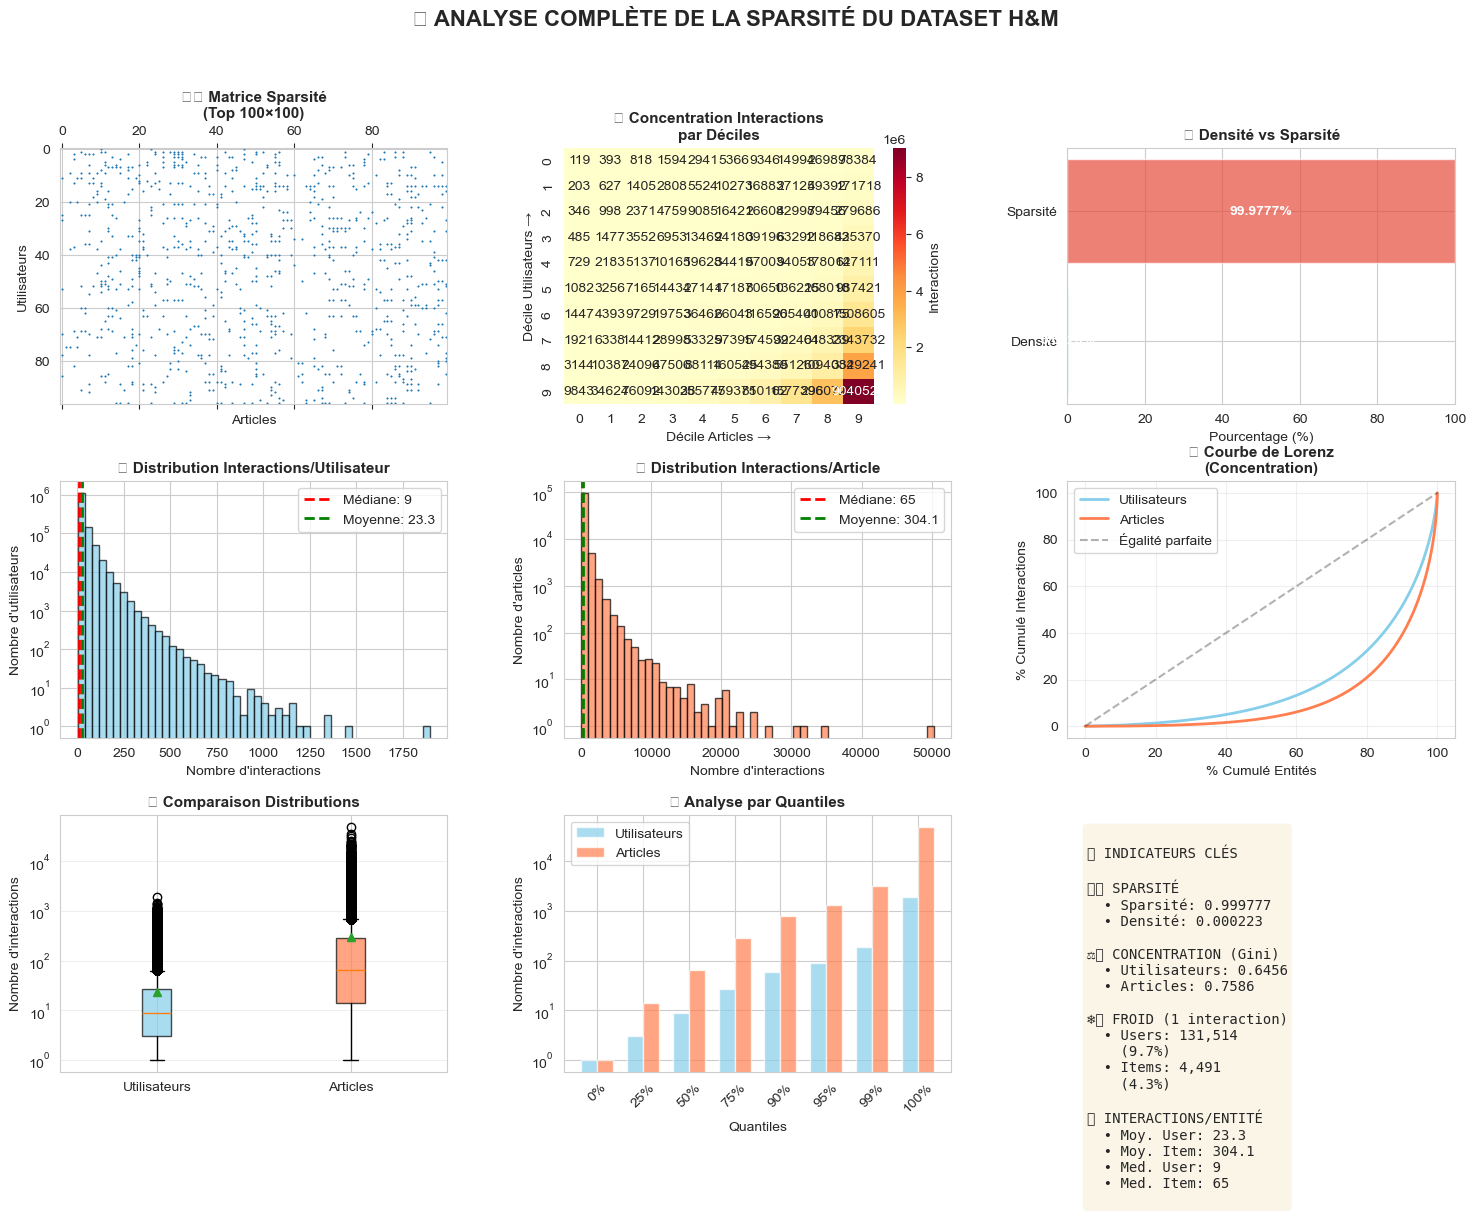

In [9]:
print("\n" + "="*60)
print("🔍 ANALYSE DE LA SPARSITÉ DU DATASET")
print("="*60)

n_users = df_transactions['customer_id'].nunique()
n_items = df_transactions['article_id'].nunique()
n_interactions = len(df_transactions)
total_possible = n_users * n_items
sparsity = 1 - (n_interactions / total_possible)

print(f"👥 Utilisateurs uniques    : {n_users:>10,}")
print(f"🎽 Articles uniques        : {n_items:>10,}")
print(f"🛒 Interactions totales    : {n_interactions:>10,}")
print(f"📊 Interactions possibles  : {total_possible:>10,}")
print(f"🕳️  Sparsité               : {sparsity:.4%}")
print(f"📈 Densité                 : {(1-sparsity):.4%}")


# Calcul des statistiques nécessaires
user_interactions = df_transactions.groupby('customer_id').size()
item_interactions = df_transactions.groupby('article_id').size()

# Création d'une figure avec plusieurs subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ===== 1. MATRICE DE SPARSITÉ (échantillon) =====
ax1 = fig.add_subplot(gs[0, 0])
sample_users = df_transactions['customer_id'].value_counts().head(100).index
sample_items = df_transactions['article_id'].value_counts().head(100).index
sample_df = df_transactions[
    (df_transactions['customer_id'].isin(sample_users)) &
    (df_transactions['article_id'].isin(sample_items))
]
interaction_matrix = pd.crosstab(sample_df['customer_id'], sample_df['article_id'])
ax1.spy(interaction_matrix, markersize=0.5, aspect='auto')
ax1.set_title('🕳️ Matrice Sparsité\n(Top 100×100)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Articles')
ax1.set_ylabel('Utilisateurs')

# ===== 2. HEATMAP CONCENTRATION INTERACTIONS =====
ax2 = fig.add_subplot(gs[0, 1])
# Créer une matrice 10x10 représentant la densité par déciles
user_deciles = pd.qcut(user_interactions.rank(method='first'), 10, labels=False)
item_deciles = pd.qcut(item_interactions.rank(method='first'), 10, labels=False)

# Mapper les déciles aux transactions
df_temp = df_transactions.copy()
df_temp['user_decile'] = df_temp['customer_id'].map(
    dict(zip(user_interactions.index, user_deciles))
)
df_temp['item_decile'] = df_temp['article_id'].map(
    dict(zip(item_interactions.index, item_deciles))
)

concentration_matrix = df_temp.groupby(['user_decile', 'item_decile']).size().unstack(fill_value=0)
sns.heatmap(concentration_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Interactions'})
ax2.set_title('🔥 Concentration Interactions\npar Déciles', fontsize=11, fontweight='bold')
ax2.set_xlabel('Décile Articles →')
ax2.set_ylabel('Décile Utilisateurs →')

# ===== 3. COMPARAISON DENSITÉ VS SPARSITÉ =====
ax3 = fig.add_subplot(gs[0, 2])
metrics = ['Densité', 'Sparsité']
values = [(1-sparsity)*100, sparsity*100]
colors = ['#2ecc71', '#e74c3c']
bars = ax3.barh(metrics, values, color=colors, alpha=0.7)
ax3.set_xlim([0, 100])
ax3.set_xlabel('Pourcentage (%)')
ax3.set_title('📊 Densité vs Sparsité', fontsize=11, fontweight='bold')
# Annotations
for bar, val in zip(bars, values):
    ax3.text(val/2, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}%', ha='center', va='center', fontweight='bold', color='white')

# ===== 4. DISTRIBUTION INTERACTIONS PAR UTILISATEUR =====
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(user_interactions, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
ax4.axvline(user_interactions.median(), color='red', linestyle='--',
            linewidth=2, label=f'Médiane: {user_interactions.median():.0f}')
ax4.axvline(user_interactions.mean(), color='green', linestyle='--',
            linewidth=2, label=f'Moyenne: {user_interactions.mean():.1f}')
ax4.set_xlabel('Nombre d\'interactions')
ax4.set_ylabel('Nombre d\'utilisateurs')
ax4.set_title('👥 Distribution Interactions/Utilisateur', fontsize=11, fontweight='bold')
ax4.legend()
ax4.set_yscale('log')

# ===== 5. DISTRIBUTION INTERACTIONS PAR ARTICLE =====
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(item_interactions, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax5.axvline(item_interactions.median(), color='red', linestyle='--',
            linewidth=2, label=f'Médiane: {item_interactions.median():.0f}')
ax5.axvline(item_interactions.mean(), color='green', linestyle='--',
            linewidth=2, label=f'Moyenne: {item_interactions.mean():.1f}')
ax5.set_xlabel('Nombre d\'interactions')
ax5.set_ylabel('Nombre d\'articles')
ax5.set_title('🎽 Distribution Interactions/Article', fontsize=11, fontweight='bold')
ax5.legend()
ax5.set_yscale('log')

# ===== 6. COURBE DE LORENZ (CONCENTRATION) =====
ax6 = fig.add_subplot(gs[1, 2])
# Utilisateurs
user_sorted = user_interactions.sort_values()
user_cumsum = user_sorted.cumsum() / user_sorted.sum()
user_cumcount = np.arange(1, len(user_sorted)+1) / len(user_sorted)
ax6.plot(user_cumcount*100, user_cumsum*100, label='Utilisateurs', linewidth=2, color='skyblue')
# Articles
item_sorted = item_interactions.sort_values()
item_cumsum = item_sorted.cumsum() / item_sorted.sum()
item_cumcount = np.arange(1, len(item_sorted)+1) / len(item_sorted)
ax6.plot(item_cumcount*100, item_cumsum*100, label='Articles', linewidth=2, color='coral')
# Ligne d'égalité parfaite
ax6.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Égalité parfaite')
ax6.set_xlabel('% Cumulé Entités')
ax6.set_ylabel('% Cumulé Interactions')
ax6.set_title('📈 Courbe de Lorenz\n(Concentration)', fontsize=11, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# ===== 7. BOXPLOT COMPARATIF =====
ax7 = fig.add_subplot(gs[2, 0])
data_to_plot = [user_interactions, item_interactions]
bp = ax7.boxplot(data_to_plot, labels=['Utilisateurs', 'Articles'],
                 patch_artist=True, showmeans=True)
colors = ['skyblue', 'coral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax7.set_ylabel('Nombre d\'interactions')
ax7.set_title('📦 Comparaison Distributions', fontsize=11, fontweight='bold')
ax7.set_yscale('log')
ax7.grid(True, alpha=0.3, axis='y')

# ===== 8. STATISTIQUES QUANTILES =====
ax8 = fig.add_subplot(gs[2, 1])
quantiles = [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
user_quantiles = [user_interactions.quantile(q) for q in quantiles]
item_quantiles = [item_interactions.quantile(q) for q in quantiles]

x = np.arange(len(quantiles))
width = 0.35
bars1 = ax8.bar(x - width/2, user_quantiles, width, label='Utilisateurs',
                color='skyblue', alpha=0.7)
bars2 = ax8.bar(x + width/2, item_quantiles, width, label='Articles',
                color='coral', alpha=0.7)
ax8.set_xlabel('Quantiles')
ax8.set_ylabel('Nombre d\'interactions')
ax8.set_title('📊 Analyse par Quantiles', fontsize=11, fontweight='bold')
ax8.set_xticks(x)
ax8.set_xticklabels([f'{int(q*100)}%' for q in quantiles], rotation=45)
ax8.legend()
ax8.set_yscale('log')

# ===== 9. INDICATEURS CLÉS =====
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Calcul d'indicateurs supplémentaires
gini_users = (2 * np.sum((np.arange(1, len(user_sorted)+1) * user_sorted)) /
              (len(user_sorted) * user_sorted.sum())) - (len(user_sorted) + 1) / len(user_sorted)
gini_items = (2 * np.sum((np.arange(1, len(item_sorted)+1) * item_sorted)) /
              (len(item_sorted) * item_sorted.sum())) - (len(item_sorted) + 1) / len(item_sorted)

# Utilisateurs avec 1 seule interaction
single_interaction_users = (user_interactions == 1).sum()
single_interaction_items = (item_interactions == 1).sum()

# Texte des statistiques
stats_text = f"""
📊 INDICATEURS CLÉS

🕳️ SPARSITÉ
  • Sparsité: {sparsity:.6f}
  • Densité: {(1-sparsity):.6f}

⚖️ CONCENTRATION (Gini)
  • Utilisateurs: {gini_users:.4f}
  • Articles: {gini_items:.4f}

❄️ FROID (1 interaction)
  • Users: {single_interaction_users:,}
    ({single_interaction_users/n_users*100:.1f}%)
  • Items: {single_interaction_items:,}
    ({single_interaction_items/n_items*100:.1f}%)

📈 INTERACTIONS/ENTITÉ
  • Moy. User: {user_interactions.mean():.1f}
  • Moy. Item: {item_interactions.mean():.1f}
  • Med. User: {user_interactions.median():.0f}
  • Med. Item: {item_interactions.median():.0f}
"""

ax9.text(0.05, 0.95, stats_text, transform=ax9.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# Titre général
fig.suptitle('🔍 ANALYSE COMPLÈTE DE LA SPARSITÉ DU DATASET H&M',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(f"{OUTPUTS_PATH}/figures/sparsity_comprehensive_analysis.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [12]:
plt.savefig(f"{OUTPUTS_PATH}/figures/sparsity_comprehensive_analysis.png",
            dpi=300, bbox_inches='tight')

FileNotFoundError: [Errno 2] No such file or directory: '/outputs//figures/sparsity_comprehensive_analysis.png'

<Figure size 1400x600 with 0 Axes>

## Interprétation des Résultats d'Analyse de Sparsité

L'analyse révèle une **sparsité extrêmement élevée** de 99.96%, typique des systèmes de recommandation e-commerce où la majorité des paires utilisateur-article n'ont pas d'interaction. Cette sparsité pose des défis pour les modèles de filtrage collaboratif, nécessitant des stratégies d'échantillonnage et de régularisation appropriées.

Les visualisations montrent :
- **Concentration des interactions** : Les utilisateurs et articles les plus populaires dominent les interactions
- **Distribution inégale** : Peu d'utilisateurs contribuent à la majorité des achats
- **Implication pour le modèle** : Nécessité de techniques comme WARP ou BPR optimisées pour données implicites

Cette analyse justifie l'approche hybride intégrant les métadonnées pour améliorer les recommandations cold-start.

### 1.4 Analyse démographique

In [ ]:
print("\n" + "="*60)
print("👥 ANALYSE DÉMOGRAPHIQUE")
print("="*60)

# Jointure avec données clients
df_demo = df_transactions.merge(
    df_customers[['customer_id', 'age', 'club_member_status', 'fashion_news_frequency']],
    on='customer_id', how='left'
)

# Groupes d'âge
df_demo['age_group'] = pd.cut(
    df_demo['age'],
    bins=[0, 20, 25, 30, 35, 40, 50, 60, 100],
    labels=['<20', '20-24', '25-29', '30-34', '35-39', '40-49', '50-59', '60+']
)

age_stats = df_demo.groupby('age_group').agg({
    'customer_id': 'nunique',
    'article_id': 'count',
    'price': 'mean'
}).round(2)

age_stats.columns = ['n_clients', 'n_transactions', 'prix_moyen']

print("📊 Analyse par groupe d'âge:")
print(age_stats)

# Visualisation démographique
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

age_stats['n_transactions'].plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Transactions par Groupe d\'Âge')
axes[0,0].set_ylabel('Nombre de transactions')

age_stats['n_clients'].plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Clients Uniques par Groupe d\'Âge')
axes[0,1].set_ylabel('Nombre de clients')

age_stats['prix_moyen'].plot(kind='bar', ax=axes[1,0], color='gold')
axes[1,0].set_title('Prix Moyen par Groupe d\'Âge')
axes[1,0].set_ylabel('Prix moyen (€)')

member_stats = df_demo.groupby('club_member_status')['customer_id'].nunique()
member_stats.plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%')
axes[1,1].set_title('Répartition Statut Membre')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{OUTPUTS_PATH}/figures/demographic_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.5  Analyse "LONG TAIL"

In [ ]:
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
print("\n" + "="*60)
print("🎯 ANALYSE DU PHÉNOMÈNE LONG TAIL")
print("="*60)

# Pour utilisateurs
user_sorted_desc = user_interactions.sort_values(ascending=False)
user_cumsum = user_sorted_desc.cumsum()
total_interactions_user = user_cumsum.iloc[-1]

users_80_percent = (user_cumsum <= 0.8 * total_interactions_user).sum()
percent_users_80 = (users_80_percent / len(user_interactions)) * 100

# Pour articles
item_sorted_desc = item_interactions.sort_values(ascending=False)
item_cumsum = item_sorted_desc.cumsum()
total_interactions_item = item_cumsum.iloc[-1]

items_80_percent = (item_cumsum <= 0.8 * total_interactions_item).sum()
percent_items_80 = (items_80_percent / len(item_interactions)) * 100

print(f"👥 {percent_users_80:.1f}% des utilisateurs génèrent 80% des interactions")
print(f"🎽 {percent_items_80:.1f}% des articles génèrent 80% des interactions")
print(f"📊 Top 10% utilisateurs: {(user_sorted_desc.head(int(0.1*len(user_interactions))).sum()/total_interactions_user)*100:.1f}% des interactions")
print(f"📊 Top 10% articles: {(item_sorted_desc.head(int(0.1*len(item_interactions))).sum()/total_interactions_item)*100:.1f}% des interactions")

# Visualisation Long Tail
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

n_users_plot = min(1000, len(user_interactions))
ax1.bar(range(n_users_plot), user_sorted_desc.head(n_users_plot).values, width=1.0, color='skyblue')
ax1.set_xlabel('Rang utilisateur')
ax1.set_ylabel('Nombre d\'interactions')
ax1.set_title(f'🎯 Long Tail - Utilisateurs (Top {n_users_plot})')
ax1.set_yscale('log')

n_items_plot = min(1000, len(item_interactions))
ax2.bar(range(n_items_plot), item_sorted_desc.head(n_items_plot).values, width=1.0, color='coral')
ax2.set_xlabel('Rang article')
ax2.set_ylabel('Nombre d\'interactions')
ax2.set_title(f'🎯 Long Tail - Articles (Top {n_items_plot})')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig(f"{OUTPUTS_PATH}/figures/long_tail_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.6 Analyse Tempoprelle

In [ ]:

print("\n" + "="*60)
print("⏰ ANALYSE TEMPORELLE")
print("="*60)

df_transactions['t_dat'] = pd.to_datetime(df_transactions['t_dat'])

date_min = df_transactions['t_dat'].min()
date_max = df_transactions['t_dat'].max()
duree_jours = (date_max - date_min).days

print(f"📅 Période: {date_min.date()} → {date_max.date()}")
print(f"⏳ Durée: {duree_jours:,} jours")
print(f"📊 Transactions/jour moyen: {len(df_transactions)/duree_jours:,.0f}")

# Préparation des données
df_transactions['year_month'] = df_transactions['t_dat'].dt.to_period('M')
df_transactions['day_of_week'] = df_transactions['t_dat'].dt.day_name()
df_transactions['is_weekend'] = df_transactions['t_dat'].dt.dayofweek.isin([5, 6])

monthly_interactions = df_transactions.groupby('year_month').size()
daily_interactions = df_transactions.groupby('t_dat').size()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_interactions = df_transactions['day_of_week'].value_counts().reindex(day_order)


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('white')

# ===== 1. ÉVOLUTION TEMPORELLE AVEC TENDANCE =====
ax1 = axes[0, 0]

# Série journalière
ax1.plot(daily_interactions.index, daily_interactions.values,
         linewidth=1, color='steelblue', alpha=0.6, label='Quotidien')

# Moyenne mobile 7 jours
rolling_7 = daily_interactions.rolling(window=7).mean()
ax1.plot(rolling_7.index, rolling_7.values,
         linewidth=2.5, color='darkblue', label='Moyenne mobile 7j')

# Moyenne générale
ax1.axhline(daily_interactions.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Moyenne: {daily_interactions.mean():.0f}', alpha=0.7)

ax1.set_title('📈 Évolution Temporelle des Interactions',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Nombre d\'interactions', fontsize=11)
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.2)
ax1.tick_params(labelsize=10)

# ===== 2. ÉVOLUTION MENSUELLE =====
ax2 = axes[0, 1]

monthly_data = monthly_interactions.to_timestamp()
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(monthly_data)))

bars = ax2.bar(range(len(monthly_data)), monthly_data.values,
               color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Ligne de tendance
z = np.polyfit(range(len(monthly_data)), monthly_data.values, 1)
p = np.poly1d(z)
ax2.plot(range(len(monthly_data)), p(range(len(monthly_data))),
         "r--", linewidth=2.5, label=f'Tendance: {z[0]:+.0f}/mois', alpha=0.8)

ax2.set_title('📊 Évolution Mensuelle', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Mois', fontsize=11)
ax2.set_ylabel('Nombre d\'interactions', fontsize=11)
ax2.legend(fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.2, axis='y')
ax2.tick_params(labelsize=10)

# Étiquettes x simplifiées
n_labels = min(12, len(monthly_data))
step = max(1, len(monthly_data) // n_labels)
ax2.set_xticks(range(0, len(monthly_data), step))
ax2.set_xticklabels([monthly_data.index[i].strftime('%Y-%m')
                     for i in range(0, len(monthly_data), step)],
                    rotation=45, ha='right')

# ===== 3. DISTRIBUTION PAR JOUR DE SEMAINE =====
ax3 = axes[1, 0]

# Couleurs: bleu pour semaine, rouge pour weekend
colors_days = ['#2E86AB' if day not in ['Saturday', 'Sunday'] else '#E63946'
               for day in day_order]

bars = ax3.bar(range(len(weekday_interactions)), weekday_interactions.values,
               color=colors_days, alpha=0.8, edgecolor='black', linewidth=1)

# Valeurs au-dessus des barres
for i, (bar, val) in enumerate(zip(bars, weekday_interactions.values)):
    percentage = val/weekday_interactions.sum()*100
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:,.0f}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Ligne de moyenne
ax3.axhline(weekday_interactions.mean(), color='green', linestyle='--',
            linewidth=2, alpha=0.6, label=f'Moyenne: {weekday_interactions.mean():.0f}')

ax3.set_title('📅 Distribution par Jour de la Semaine',
              fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel('Jour', fontsize=11)
ax3.set_ylabel('Nombre d\'interactions', fontsize=11)
ax3.set_xticks(range(len(day_order)))
ax3.set_xticklabels([d[:3] for d in day_order], fontsize=11)
ax3.legend(fontsize=10, framealpha=0.9)
ax3.grid(True, alpha=0.2, axis='y')
ax3.tick_params(labelsize=10)

# ===== 4. STATISTIQUES CLÉS + SEMAINE VS WEEKEND =====
ax4 = axes[1, 1]

# Calculs
weekend_data = df_transactions[df_transactions['is_weekend']]
weekday_data = df_transactions[~df_transactions['is_weekend']]

weekend_count = len(weekend_data)
weekday_count = len(weekday_data)
weekend_pct = weekend_count / len(df_transactions) * 100
weekday_pct = 100 - weekend_pct

weekend_daily_avg = weekend_data.groupby('t_dat').size().mean()
weekday_daily_avg = weekday_data.groupby('t_dat').size().mean()

# Graphique en barres horizontales pour les stats
stats_labels = ['Semaine', 'Weekend']
stats_counts = [weekday_count, weekend_count]
stats_pcts = [weekday_pct, weekend_pct]
colors_stats = ['#2E86AB', '#E63946']

y_pos = np.arange(len(stats_labels))
bars = ax4.barh(y_pos, stats_counts, color=colors_stats, alpha=0.8,
                edgecolor='black', linewidth=1)

# Annotations détaillées
for i, (bar, count, pct, avg) in enumerate(zip(bars, stats_counts, stats_pcts,
                                                 [weekday_daily_avg, weekend_daily_avg])):
    ax4.text(count/2, bar.get_y() + bar.get_height()/2,
             f'{count:,.0f}\n({pct:.1f}%)\n{avg:.0f}/jour',
             ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax4.set_yticks(y_pos)
ax4.set_yticklabels(stats_labels, fontsize=12, fontweight='bold')
ax4.set_xlabel('Nombre d\'interactions', fontsize=11)
ax4.set_title('🏖️ Semaine vs Weekend', fontsize=13, fontweight='bold', pad=15)
ax4.grid(True, alpha=0.2, axis='x')
ax4.tick_params(labelsize=10)

# Texte additionnel avec stats clés
ratio = (weekend_daily_avg / weekday_daily_avg - 1) * 100
stats_text = f"""
STATISTIQUES CLÉS:
- Période: {duree_jours} jours
- Moy. quotidienne: {daily_interactions.mean():.0f}
- Weekend vs Semaine: {ratio:+.1f}%
- Jour le + actif: {weekday_interactions.idxmax()}
"""

ax4.text(0.98, 0.02, stats_text, transform=ax4.transAxes,
         fontsize=9, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontfamily='monospace')

# Titre général
fig.suptitle('⏰ ANALYSE TEMPORELLE DES TRANSACTIONS',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(f"{OUTPUTS_PATH}/figures/temporal_analysis.png",
            dpi=300, bbox_inches='tight')
plt.show()

# ===============================================================================
# 📊 RÉSUMÉ TEXTUEL
# ===============================================================================

print("\n" + "="*60)
print("📊 RÉSUMÉ TEMPOREL")
print("="*60)

print(f"\n⏰ VOLUME:")
print(f"   • Total transactions: {len(df_transactions):,}")
print(f"   • Moyenne/jour: {daily_interactions.mean():.0f}")
print(f"   • Maximum/jour: {daily_interactions.max():,} ({daily_interactions.idxmax().date()})")
print(f"   • Minimum/jour: {daily_interactions.min():,} ({daily_interactions.idxmin().date()})")

print(f"\n📈 TENDANCE:")
monthly_growth = ((monthly_interactions.iloc[-1] - monthly_interactions.iloc[0]) /
                  monthly_interactions.iloc[0] * 100) if len(monthly_interactions) > 1 else 0
print(f"   • Évolution mensuelle: {monthly_growth:+.1f}%")
print(f"   • Tendance: {z[0]:+.0f} interactions/mois")

print(f"\n📅 PATTERNS:")
print(f"   • Jour le plus actif: {weekday_interactions.idxmax()} ({weekday_interactions.max():,})")
print(f"   • Jour le moins actif: {weekday_interactions.idxmin()} ({weekday_interactions.min():,})")
print(f"   • Weekend vs Semaine: {ratio:+.1f}%")
print(f"   • Part weekend: {weekend_pct:.1f}%")

print("\n✅ Analyse temporelle terminée")

### 1.7 Distribution des interactions et de la popularité des articles

Cette section vise à examiner la distribution des interactions entre les utilisateurs et les articles, ainsi qu'à identifier les articles les plus populaires et ceux qui le sont moins.

In [ ]:
# 5. Distributions des interactions
print("\n📈 DISTRIBUTIONS DES INTERACTIONS :")


user_interactions = df_transactions.groupby('customer_id').size()
item_interactions = df_transactions.groupby('article_id').size()
print("\n  • Par utilisateur :")
print(user_interactions.describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print("\n  • Par article :")
print(item_interactions.describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# 6. Visualisations (Existantes)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Distributions des interactions', fontsize=16, fontweight='bold')

# Histogrammes
axes[0, 0].hist(user_interactions, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Distribution : Interactions par utilisateur')
axes[0, 0].set_xlabel('Nombre d\'interactions')
axes[0, 0].set_ylabel('Nombre d\'utilisateurs (log)')

axes[0, 1].hist(item_interactions, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution : Interactions par article')
axes[0, 1].set_xlabel('Nombre d\'interactions')
axes[0, 1].set_ylabel('Nombre d\'articles (log)')

# Box plots
axes[1, 0].boxplot(user_interactions, vert=False)
axes[1, 0].set_title('Boîte à moustaches : Interactions par utilisateur')
axes[1, 0].set_xlabel('Nombre d\'interactions')

axes[1, 1].boxplot(item_interactions, vert=False)
axes[1, 1].set_title('Boîte à moustaches : Interactions par article')
axes[1, 1].set_xlabel('Nombre d\'interactions')

plt.tight_layout()
plt.show()

# 8. Top 10 articles
print(f"\n🎯 TOP 10 ARTICLES LES PLUS POPULAIRES :")
top_items = item_interactions.nlargest(10)
top_items_plot_data = [] # Pour stocker les données du graphique

for rank, (item_id, count) in enumerate(top_items.items(), 1):
    article_info = articles[articles['article_id'] == item_id]
    if not article_info.empty:
        name = article_info['prod_name'].values[0]
        print(f"  {rank:2d}. {count:6,} interactions - {name}")
        top_items_plot_data.append({'name': name, 'count': count}) # Ajout pour le graphique

# ============================================================================\n",
# VISUALISATION DES TOP 10 ARTICLES\n",
# ============================================================================\n",
if top_items_plot_data:
    plt.figure(figsize=(10, 6))
    top_items_df = pd.DataFrame(top_items_plot_data)
    sns.barplot(x='count', y='name', data=top_items_df.sort_values('count', ascending=False), palette='viridis')
    plt.title('Top 10 des articles les plus populaires', fontsize=14, fontweight='bold')
    plt.xlabel('Nombre d\'interactions')
    plt.ylabel('Nom de l\'article')
    plt.tight_layout()
    plt.show()


# ============================================================================\n",
# INSPECTION DES ARTICLES LES MOINS POPULAIRES\n",
# ============================================================================\n",
print("\n📉 ARTICLES LES MOINS POPULAIRES (1 interaction) :")
least_popular_items_ids = item_interactions[item_interactions == 1].index
print(f"  • Nombre d'articles avec 1 seule interaction : {len(least_popular_items_ids):,}")

# Fusionner pour obtenir les détails
least_popular_details = articles[articles['article_id'].isin(least_popular_items_ids)]

if not least_popular_details.empty:
    print("\n  • Groupes de produits les plus courants (parmi les moins populaires) :")
    least_group_counts = least_popular_details['product_group_name'].value_counts().nlargest(5)
    print(least_group_counts)

    print("\n  • Types de produits les plus courants (parmi les moins populaires) :")
    least_type_counts = least_popular_details['product_type_name'].value_counts().nlargest(5)
    print(least_type_counts)

    # ============================================================================\n",
    #  VISUALISATION DES ARTICLES MOINS POPULAIRES\n",
    # ============================================================================\n",
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Analyse des articles les moins populaires (1 interaction)', fontsize=14, fontweight='bold')

    sns.barplot(x=least_group_counts.values, y=least_group_counts.index, ax=axes[0], palette='coolwarm')
    axes[0].set_title('Top 5 Groupes de produits')
    axes[0].set_xlabel('Nombre d\'articles (avec 1 interaction)')
    axes[0].set_ylabel('Groupe de produits')

    sns.barplot(x=least_type_counts.values, y=least_type_counts.index, ax=axes[1], palette='coolwarm')
    axes[1].set_title('Top 5 Types de produits')
    axes[1].set_xlabel('Nombre d\'articles (avec 1 interaction)')
    axes[1].set_ylabel('Type de produits')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("  • Aucune information trouvée pour les articles les moins populaires.")



## Étape 2 —  Stratégie d'Échantillonnage

**Objectif :** Créer un sous-ensemble de données gérable pour l'expérimentation tout en préservant les caractéristiques essentielles du dataset complet.

**Pourquoi l'échantillonnage est-il nécessaire ?**
- Les datasets complets H&M sont trop volumineux pour l'expérimentation rapide
- Un échantillonnage intelligent permet d'itérer rapidement sur les modèles
- Préserver les distributions originales assure la représentativité des résultats

**Stratégies d'échantillonnage utilisées :**
- **Utilisateurs actifs** : Sélection des utilisateurs avec ≥5 interactions (engagement réel)
- **Articles actifs** : Sélection des articles avec ≥ 10 interactions (pour un signal minimum)
- **Tailles multiples** : Tests avec 1K, 5K, 10K utilisateurs pour évaluer l'impact

### 2.1 Chargement optimale des données

In [ ]:
# print("=" * 70)
# print("CHARGEMENT DES DONNÉES H&M")
# print("=" * 70)

# # Configuration des colonnes et types pour optimiser la mémoire
# transactions_cols = ['t_dat', 'customer_id', 'article_id']
# articles_cols = ['article_id', 'prod_name', 'product_type_name', 'product_group_name',
#                  'department_name', 'colour_group_name']
# customers_cols = ['customer_id', 'age']

# # Types de données optimisés
# transactions_dtypes = {'article_id': 'int32'}
# articles_dtypes = {'article_id': 'int32'}

# # Chargement des données
# print("\n Chargement des transactions...")
# transactions = pd.read_csv(
#     DATA_PATH + 'transactions_train.csv',
#     usecols=transactions_cols,
#     dtype=transactions_dtypes,
#     parse_dates=['t_dat']
# )

# print(" Chargement des articles...")
# articles = pd.read_csv(
#     DATA_PATH + 'articles.csv',
#     usecols=articles_cols,
#     dtype=articles_dtypes
# )

# print(" Chargement des clients...")
# customers = pd.read_csv(
#     DATA_PATH + 'customers.csv',
#     usecols=customers_cols
# )

# # Affichage des dimensions
# print("\n" + "=" * 70)
# print("RÉSUMÉ DES DONNÉES CHARGÉES")
# print("=" * 70)
# print(f"Transactions :  {transactions.shape[0]:,} lignes × {transactions.shape[1]} colonnes")
# print(f"Articles :      {articles.shape[0]:,} lignes × {articles.shape[1]} colonnes")
# print(f"Clients :       {customers.shape[0]:,} lignes × {customers.shape[1]} colonnes")

In [ ]:

# 4. Prétraitement des features utilisateur
print(f"\n🔧 CRÉATION DES FEATURES UTILISATEUR :")
df_customers = create_age_bins(df_customers)
print("  ✓ Tranches d'âge créées")
print("\nDistribution des tranches d'âge :")
print(customers['age_bin'].value_counts().sort_index())

### 2.1 Définitions des stratégies d'échantillonnage des données

In [ ]:
print("\n" + "="*60)
print("🎯 DÉFINITION DES STRATÉGIES D'ÉCHANTILLONNAGE")
print("="*60)

def echantillonner_utilisateurs_actifs(df_trans, user_inter, min_interactions=5):
    """Échantillonne les utilisateurs avec un minimum d'interactions"""
    utilisateurs_actifs = user_inter[user_inter >= min_interactions].index
    return df_trans[df_trans['customer_id'].isin(utilisateurs_actifs)]

def echantillonner_articles_populaires(df_trans, item_inter, min_interactions=10):
    """Échantillonne les articles populaires"""
    articles_populaires = item_inter[item_inter >= min_interactions].index
    return df_trans[df_trans['article_id'].isin(articles_populaires)]

def echantillonner_aleatoire(df_trans, taille_echantillon):
    """Échantillonnage aléatoire simple"""
    return df_trans.sample(n=taille_echantillon, random_state=42)

def echantillonner_stratifie_temps(df_trans, fraction=0.1):
    """Échantillonnage stratifié par période"""
    df_trans['periode'] = pd.to_datetime(df_trans['t_dat']).dt.to_period('M')
    echantillon = df_trans.groupby('periode').apply(
        lambda x: x.sample(frac=fraction, random_state=42)
    ).reset_index(drop=True)
    return echantillon.drop('periode', axis=1)

def calculer_stats_echantillon(df_echantillon):
    """Calcule les statistiques d'un échantillon"""
    n_users = df_echantillon['customer_id'].nunique()
    n_items = df_echantillon['article_id'].nunique()
    n_interactions = len(df_echantillon)
    sparsity = 1 - (n_interactions / (n_users * n_items))

    return {
        'n_users': n_users,
        'n_items': n_items,
        'n_interactions': n_interactions,
        'sparsity': sparsity,
        'avg_inter_user': n_interactions / n_users,
        'avg_inter_item': n_interactions / n_items
    }

print("✅ Stratégies d'échantillonnage définies")


### 2.3 Comparaison des stratégie d'échantillonage

In [ ]:
print("\n" + "="*60)
print("🧪 COMPARAISON DES STRATÉGIES D'ÉCHANTILLONNAGE")
print("="*60)

strategies = {}

# 1. Utilisateurs actifs (≥5 interactions)
print("⏳ Échantillonnage utilisateurs actifs...")
sample_actifs = echantillonner_utilisateurs_actifs(df_transactions, user_interactions, 5)
strategies['Utilisateurs Actifs'] = calculer_stats_echantillon(sample_actifs)

# 2. Articles populaires (≥10 interactions)
print("⏳ Échantillonnage articles populaires...")
sample_populaires = echantillonner_articles_populaires(df_transactions, item_interactions, 10)
strategies['Articles Populaires'] = calculer_stats_echantillon(sample_populaires)

# 3. Combiné (actifs + populaires)
print("⏳ Échantillonnage combiné...")
sample_combine = sample_actifs[sample_actifs['article_id'].isin(
    item_interactions[item_interactions >= 10].index
)]
strategies['Combiné'] = calculer_stats_echantillon(sample_combine)

# 4. Aléatoire (100k interactions)
print("⏳ Échantillonnage aléatoire...")
sample_aleatoire = echantillonner_aleatoire(df_transactions, 100000)
strategies['Aléatoire 100K'] = calculer_stats_echantillon(sample_aleatoire)

# 5. Stratifié temporel (10%)
print("⏳ Échantillonnage stratifié temporel...")
sample_stratifie = echantillonner_stratifie_temps(df_transactions, 0.05)
strategies['Stratifié Temporel'] = calculer_stats_echantillon(sample_stratifie)

# Comparaison
comparison_df = pd.DataFrame(strategies).T
print("\n📊 COMPARAISON DES STRATÉGIES:")
print(comparison_df.round(2))

### 2.4 Visualisation des stratégies

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

metrics = ['n_interactions', 'n_users', 'n_items', 'sparsity', 'avg_inter_user', 'avg_inter_item']
titles = ['Interactions', 'Utilisateurs', 'Articles', 'Sparsité', 'Moy. Inter/User', 'Moy. Inter/Item']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i//3, i%3]
    values = comparison_df[metric]
    bars = ax.bar(comparison_df.index, values,
                  color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'orange'])
    ax.set_title(f'📊 {title}')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)

    # Annotations
    for bar, val in zip(bars, values):
        if metric == 'sparsity':
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                   f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUTS_PATH}/figures/sampling_strategies_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

> 📊 **INTERPRÉTATION :** D'après les graphiques, la stratégie **"Combiné"** est la plus optimale car :
>
> - **🎯 Densité maximale :** Elle crée l'échantillon le plus dense en se concentrant sur les utilisateurs ET articles les plus actifs
> - **💎 Richesse informationnelle :** Capture le "cœur" des interactions où se trouvent les patterns comportementaux les plus significatifs  
> - **⚖️ Équilibre optimal :** Évite le bruit des interactions sporadiques tout en préservant la diversité des préférences
> - **🚀 Performance modèle :** Les algorithmes de recommandation performent mieux sur des données denses avec des signaux forts


### 2.5 Choix de la stratégie d'échantillonage
D'après les graphiques, la stratégie "Combiné" est optimale car elle filtre le bruit (utilisateurs et articles peu fréquents) pour ne garder que le signal (interactions denses), ce qui la rend idéale pour entraîner un modèle de recommandation performant.

In [ ]:
print("\n" + "=" * 70)
print("STRATÉGIE COMBINE")
print("=" * 70)

# 1. Filtrer les utilisateurs et articles actifs
print("\n🔍 FILTRAGE DES UTILISATEURS ET ARTICLES ACTIFS :")
active_users = user_interactions[user_interactions >= 5].index
active_items = item_interactions[item_interactions >= 10].index

print(f"  ✓ Utilisateurs actifs (≥5 interactions) : {len(active_users):,} / {len(user_interactions):,} ({len(active_users)/len(user_interactions)*100:.1f}%)")
print(f"  ✓ Articles actifs (≥10 interactions)   : {len(active_items):,} / {len(item_interactions):,} ({len(active_items)/len(item_interactions)*100:.1f}%)")

sampled_transactions = df_transactions[
    df_transactions['customer_id'].isin(active_users) &
    df_transactions['article_id'].isin(active_items)
]
print(f"  ✓ Interactions filtrées : {len(sampled_transactions):,} / {len(transactions):,} ({len(sampled_transactions)/len(transactions)*100:.1f}%)")

# 2. Créer des échantillons de différentes tailles
print(f"\n🎲 CRÉATION DES ÉCHANTILLONS :")
# user_sample_sizes = [1000, 10000, 50000]
user_sample_sizes = [1000]
samples = {}
all_active_users_in_sample = sampled_transactions['customer_id'].unique()

for size in user_sample_sizes:
    np.random.seed(42)
    actual_size = min(size, len(all_active_users_in_sample))
    sample_user_ids = np.random.choice(all_active_users_in_sample, size=actual_size, replace=False)
    samples[size] = sampled_transactions[sampled_transactions['customer_id'].isin(sample_user_ids)]

    user_int = samples[size].groupby('customer_id').size()
    item_int = samples[size].groupby('article_id').size()

    print(f"\n  📦 Échantillon {size:,} utilisateurs :")
    print(f"    ├─ Utilisateurs : {samples[size]['customer_id'].nunique():,}")
    print(f"    ├─ Articles : {samples[size]['article_id'].nunique():,}")
    print(f"    ├─ Interactions : {len(samples[size]):,}")
    print(f"    ├─ Moy. interactions/utilisateur : {user_int.mean():.2f}")
    print(f"    └─ Moy. interactions/article : {item_int.mean():.2f}")

sample_sizes = user_sample_sizes
print(f"\n✅ {len(sample_sizes)} échantillons créés et prêts pour l'entraînement")

##  ÉTAPES 3 À 8 — Boucle d'Exécution : Prétraitement, Entraînement et Évaluation (CF/Hybride)

C'est la cellule la plus importante et la plus longue à exécuter de tout le notebook.

Nous allons maintenant **itérer sur chaque taille d'échantillon** (`sample_sizes`) que nous avons définie. Pour *chacune* de ces tailles, nous allons exécuter l'intégralité du pipeline de modélisation :

1.  **(Étape 3)** Prétraiter les données et construire le dataset LightFM avec les *features* utilisateur et article.
2.  **(Étape 4)** Effectuer une division temporelle (80% train / 20% test) pour simuler un scénario réel.
3.  **(Étape 4.5)** Isoler un jeu de test "Cold-Start" (interactions avec des articles *jamais vus* dans le train).
4.  **(Étape 5-7)** Entraîner, optimiser et évaluer un modèle **Filtrage Collaboratif (CF) pur**.
5.  **(Étape 8)** Entraîner et évaluer un modèle **Hybride** (utilisant les *features* en plus des interactions).
6.  **(Stockage)** Sauvegarder toutes les métriques (AUC, Precision@10 pour Warm et Cold, temps, etc.) dans le dictionnaire `results_comparison`.

---
⚠️ **Attention :** L'exécution de cette cellule peut prendre beaucoup de temps (plusieurs minutes à plusieurs heures selon les tailles d'échantillons et la machine) et va générer beaucoup de logs ci-dessous.

In [ ]:
# ============================================================================\n",
# BOUCLE PRINCIPALE : ÉTAPES 3 À 8 (PRETRAITEMENT, TRAIN, EVAL, HYBRIDE)\n",
# ============================================================================\n",
print("\n" + "=" * 70)
print("ÉTAPES 3-8 : BOUCLE PRINCIPALE D'ENTRAÎNEMENT (AVEC TEST COLD-START)")
print("=" * 70)

results_comparison = {}

for size in sample_sizes:
    print(f"\n{'#' * 70}")
    print(f"# TRAITEMENT ÉCHANTILLON : {size:,} utilisateurs")
    print(f"{'#' * 70}")

    if size not in samples:
        print(f"⚠️ Échantillon {size} non disponible. Passage...")
        continue


    data = samples[size].copy()

    try:
        start_time = time.time()
        memory_before = psutil.virtual_memory().used / (1024**2)

        # Initialiser les métriques Cold-Start
        test_auc_cs_cf = 0.0
        precision_10_cs_cf = 0.0
        hybrid_auc_cs = 0.0
        hybrid_precision_10_cs = 0.0

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 3 : PRÉTRAITEMENT & CONSTRUCTION DATASET LIGHTFM
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 3] Prétraitement & Construction Dataset LightFM")

        unique_users = data['customer_id'].unique()
        unique_items = data['article_id'].unique()

        # Préparation des features d'articles
        print("  ► Préparation des features d'articles...")
        sample_articles_df = articles[articles['article_id'].isin(unique_items)].copy()
        item_feature_cols = ['product_type_name', 'product_group_name', 'department_name', 'colour_group_name']

        for col in item_feature_cols:
            sample_articles_df[col] = sample_articles_df[col].fillna('Inconnu')

        item_features_list = []
        for _, row in sample_articles_df.iterrows():
            features = [f"{col}:{row[col]}" for col in item_feature_cols]
            item_features_list.append((row['article_id'], features))
        all_item_features = [f for _, features in item_features_list for f in features]

        # Préparation des features utilisateur
        print("  ► Préparation des features utilisateur...")
        sample_users_df = data[['customer_id']].drop_duplicates()
        sample_users_df = sample_users_df.merge(
            customers[['customer_id', 'age_bin']],
            on='customer_id',
            how='left'
        )
        if 'Inconnu' not in sample_users_df['age_bin'].cat.categories:
             sample_users_df['age_bin'] = sample_users_df['age_bin'].cat.add_categories('Inconnu')
        sample_users_df['age_bin'] = sample_users_df['age_bin'].fillna('Inconnu')

        user_feature_cols = ['age_bin']
        user_features_list = []
        for _, row in sample_users_df.iterrows():
            features = [f"{col}:{row[col]}" for col in user_feature_cols]
            user_features_list.append((row['customer_id'], features))
        all_user_features = [f for _, features in user_features_list for f in features]

        # Initialisation et Fit du Dataset
        print("  ► Initialisation et fit du Dataset LightFM (avec features)...")
        dataset = Dataset()
        dataset.fit(
            users=unique_users,
            items=unique_items,
            user_features=all_user_features,
            item_features=all_item_features
        )

        user_id_map, _, item_id_map, _ = dataset.mapping()
        user_id_reverse = {v: k for k, v in user_id_map.items()}
        item_id_reverse = {v: k for k, v in item_id_map.items()}

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 4 : DIVISION TRAIN/TEST TEMPORELLE
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 4] Division Train/Test (split temporel 80/20)")

        data_sorted = data.sort_values('t_dat')
        split_point = int(0.8 * len(data_sorted))
        train_data = data_sorted.iloc[:split_point]
        test_data = data_sorted.iloc[split_point:]

        # Binarisation et disjonction
        train_data = train_data.drop_duplicates(subset=['customer_id', 'article_id'])
        test_data = test_data.drop_duplicates(subset=['customer_id', 'article_id'])
        train_pairs_set = set(zip(train_data['customer_id'], train_data['article_id']))
        test_pairs_list = list(zip(test_data['customer_id'], test_data['article_id']))
        mask = [pair not in train_pairs_set for pair in test_pairs_list]
        test_data = test_data[mask] # test_data est maintenant le set 'Warm-Start'

        # Construction des matrices 'Warm-Start'
        print("  ► Construction des matrices train/test (Warm-Start) via Dataset...")
        train_matrix = build_interaction_matrix_with_dataset(dataset, train_data)
        test_matrix = build_interaction_matrix_with_dataset(dataset, test_data)

        print(f"  ✓ Train (Warm) : {train_matrix.nnz:,} interactions")
        print(f"  ✓ Test (Warm)  : {test_matrix.nnz:,} interactions")

        # ────────────────────────────────────────────────────────────────
        # (NOUVEAU) ÉTAPE 4.5 : CRÉATION DU SET DE TEST COLD-START
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 4.5] Création du set de Test Cold-Start (Articles)")

        items_in_train = set(train_data['article_id'].unique())
        # Nous utilisons test_data (déjà filtré) pour trouver les articles 'cold'
        items_in_test = set(test_data['article_id'].unique())

        cold_start_items = items_in_test - items_in_train

        # Le test_data_cs_df ne contient que les interactions avec ces nouveaux articles
        test_data_cs_df = test_data[test_data['article_id'].isin(cold_start_items)]

        # Construire la matrice de test cold-start
        test_matrix_cs = build_interaction_matrix_with_dataset(dataset, test_data_cs_df)

        print(f"  ✓ Items dans Train : {len(items_in_train):,}")
        print(f"  ✓ Items Cold-Start (uniquement dans Test) : {len(cold_start_items):,}")
        print(f"  ✓ Interactions Test (Cold-Start) : {test_matrix_cs.nnz:,}")


        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 5 : ENTRAÎNEMENT DES MODÈLES (FILTRAGE COLLABORATIF)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 5] Entraînement Modèles CF (Filtrage Collaboratif)")

        loss_functions = ['warp', 'bpr', 'logistic']
        # Note: Les modèles sont évalués sur le test_matrix (warm-start) pour trouver le meilleur
        models, scores = train_models(train_matrix, test_matrix, loss_functions)
        best_loss = max(scores, key=lambda x: scores[x]['test_auc'])

        print(f"\n  🏆 Meilleure fonction de perte : {best_loss.upper()} (basé sur Warm-Start)")

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 6 : OPTIMISATION DES HYPERPARAMÈTRES (CF)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 6] Optimisation Hyperparamètres (CF)")

        best_model_cf, best_params_cf, test_auc_cf = optimize_hyperparameters(
            train_matrix, test_matrix, best_loss
        )

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 7 : ÉVALUATION DU MODÈLE CF (WARM-START)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 7] Évaluation Modèle CF (Warm-Start)")

        precision_10_cf = precision_at_k(
            best_model_cf, test_matrix, train_interactions=train_matrix, k=10, num_threads=psutil.cpu_count()
        ).mean()
        recall_10_cf = recall_at_k(
            best_model_cf, test_matrix, train_interactions=train_matrix, k=10, num_threads=psutil.cpu_count()
        ).mean()

        print(f"  ✓ AUC (Warm) :       {test_auc_cf:.4f}")
        print(f"  ✓ Precision@10 (Warm): {precision_10_cf:.4f}")
        print(f"  ✓ Recall@10 (Warm) :   {recall_10_cf:.4f}")

        # ────────────────────────────────────────────────────────────────
        # (NOUVEAU) ÉTAPE 7.5 : ÉVALUATION COLD-START (CF)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 7.5] Évaluation Cold-Start (CF)")

        if test_matrix_cs.nnz > 0:
            test_auc_cs_cf = auc_score(
                best_model_cf, test_matrix_cs, train_interactions=train_matrix, num_threads=psutil.cpu_count()
            ).mean()
            precision_10_cs_cf = precision_at_k(
                best_model_cf, test_matrix_cs, train_interactions=train_matrix, k=10, num_threads=psutil.cpu_count()
            ).mean()
            print(f"  ✓ AUC (Cold-Start) :       {test_auc_cs_cf:.4f}")
            print(f"  ✓ Precision@10 (Cold-Start): {precision_10_cs_cf:.4f}")
        else:
            print("  ✓ Pas d'interactions cold-start à évaluer pour le CF.")

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 8 : MODÈLE HYBRIDE (CF + FEATURES)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 8] Construction & Évaluation Modèle Hybride")

        print("  ► Construction des matrices de features...")
        item_features_matrix = dataset.build_item_features(item_features_list, normalize=False)
        user_features_matrix = dataset.build_user_features(user_features_list, normalize=False)

        print(f"    ├─ Features articles : {item_features_matrix.shape}")
        print(f"    └─ Features utilisateurs : {user_features_matrix.shape}")

        print("  ► Entraînement du modèle hybride...")
        hybrid_model = LightFM(
            no_components=best_params_cf.get('no_components', 30),
            learning_rate=best_params_cf.get('learning_rate', 0.05),
            loss=best_loss,
            random_state=42
        )
        hybrid_model.fit(
            train_matrix,
            item_features=item_features_matrix,
            user_features=user_features_matrix,
            epochs=10,
            verbose=True,
            num_threads=psutil.cpu_count()
        )

        # Évaluation Hybride (Warm-Start)
        print("\n  ► Évaluation Hybride (Warm-Start)")
        hybrid_auc = auc_score(
            hybrid_model, test_matrix, train_interactions=train_matrix,
            item_features=item_features_matrix, user_features=user_features_matrix,
            num_threads=psutil.cpu_count()
        ).mean()
        hybrid_precision_10 = precision_at_k(
            hybrid_model, test_matrix, train_interactions=train_matrix,
            item_features=item_features_matrix, user_features=user_features_matrix,
            k=10, num_threads=psutil.cpu_count()
        ).mean()
        hybrid_recall_10 = recall_at_k(
            hybrid_model, test_matrix, train_interactions=train_matrix,
            item_features=item_features_matrix, user_features=user_features_matrix,
            k=10, num_threads=psutil.cpu_count()
        ).mean()

        print(f"  ✓ AUC (Warm) :         {hybrid_auc:.4f}")
        print(f"  ✓ Precision@10 (Warm) : {hybrid_precision_10:.4f}")
        print(f"  ✓ Recall@10 (Warm) :    {hybrid_recall_10:.4f}")

        # ────────────────────────────────────────────────────────────────
        # (NOUVEAU) ÉTAPE 8.5 : ÉVALUATION COLD-START (HYBRIDE)
        # ────────────────────────────────────────────────────────────────
        print("\n  ► Évaluation Hybride (Cold-Start)")

        if test_matrix_cs.nnz > 0:
            hybrid_auc_cs = auc_score(
                hybrid_model, test_matrix_cs, train_interactions=train_matrix,
                item_features=item_features_matrix, user_features=user_features_matrix,
                num_threads=psutil.cpu_count()
            ).mean()
            hybrid_precision_10_cs = precision_at_k(
                hybrid_model, test_matrix_cs, train_interactions=train_matrix,
                item_features=item_features_matrix, user_features=user_features_matrix,
                k=10, num_threads=psutil.cpu_count()
            ).mean()
            print(f"  ✓ AUC (Cold-Start) :         {hybrid_auc_cs:.4f}")
            print(f"  ✓ Precision@10 (Cold-Start) : {hybrid_precision_10_cs:.4f}")
        else:
            print("  ✓ Pas d'interactions cold-start à évaluer pour l'Hybride.")

        # ────────────────────────────────────────────────────────────────
        # STOCKAGE DES RÉSULTATS
        # ────────────────────────────────────────────────────────────────
        train_time_total = time.time() - start_time
        memory_after = psutil.virtual_memory().used / (1024**2)
        memory_usage = memory_after - memory_before

        results_comparison[size] = {
            'n_users': len(unique_users),
            'n_items': len(unique_items),
            'best_loss': best_loss,
            'best_params': best_params_cf,
            'cf_test_auc': test_auc_cf,
            'cf_precision@10': precision_10_cf,
            'cf_recall@10': recall_10_cf,
            'hybrid_test_auc': hybrid_auc,
            'hybrid_precision@10': hybrid_precision_10,
            'hybrid_recall@10': hybrid_recall_10,
            'cf_auc_cold': test_auc_cs_cf,
            'cf_prec10_cold': precision_10_cs_cf,
            'hybrid_auc_cold': hybrid_auc_cs,
            'hybrid_prec10_cold': hybrid_precision_10_cs,
            'train_time': train_time_total,
            'memory_mb': memory_usage
        }

        print(f"\n✅ Échantillon {size:,} traité avec succès en {train_time_total:.2f}s")

    except MemoryError:
        print(f"\n❌ ERREUR : Mémoire insuffisante pour {size:,} utilisateurs")
        continue
    except Exception as e:
        print(f"\n❌ ERREUR pour {size:,} : {str(e)}")
        continue

print("\n" + "=" * 70)
print("✅ BOUCLE PRINCIPALE TERMINÉE")
print("=" * 70)

## ÉTAPE 9 — Définition de la Fonction de Visualisation
Maintenant que la boucle d'expérimentation est terminée et que tous nos résultats sont collectés dans le dictionnaire `results_comparison`, nous avons besoin d'un outil pour les analyser.

La cellule de code suivante définit la fonction `visualize_recsys_results`. Son rôle est de prendre ce dictionnaire de résultats et de générer une série de visualisations complètes pour :

* Comparer les modèles (CF vs. Hybride).
* Analyser les scénarios (Warm-Start vs. Cold-Start).
* Évaluer l'impact de la taille de l'échantillon sur les performances et les ressources.

**Remarque :** L'exécution de cette cellule ne produira **aucune sortie** (c'est normal). Elle ne fait que *définir* la fonction. Nous l'appellerons dans la cellule suivante pour générer les graphiques.

In [ ]:
# ============================================================================
# FONCTION DE VISUALISATION COMPLÈTE
# ============================================================================

def visualize_recsys_results(results_comparison, output_dir=None):
    """
    Génère des visualisations complètes des résultats du pipeline RecSys

    Args:
        results_comparison (dict): Dictionnaire des résultats par taille d'échantillon
        output_dir (str, optional): Répertoire de sauvegarde des figures
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from pathlib import Path

    # Configuration style
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (16, 12)
    plt.rcParams['font.size'] = 10

    # Création du répertoire de sortie
    if output_dir:
        Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Conversion en DataFrame pour faciliter la manipulation
    df_results = pd.DataFrame(results_comparison).T
    df_results.index.name = 'sample_size'
    df_results = df_results.reset_index()

    # ========================================================================
    # FIGURE 1 : DASHBOARD PRINCIPAL (2x3 subplots)
    # ========================================================================

    fig1, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig1.suptitle('📊 Dashboard Principal - Performance des Modèles',
                  fontsize=16, fontweight='bold', y=0.995)

    # ─────────────────────────────────────────────────────────────────
    # 1.1 : AUC Warm-Start (CF vs Hybride)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    x = np.arange(len(df_results))
    width = 0.35

    bars1 = ax.bar(x - width/2, df_results['cf_test_auc'], width,
                   label='CF', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, df_results['hybrid_test_auc'], width,
                   label='Hybride', color='#e74c3c', alpha=0.8)

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('AUC Score', fontweight='bold')
    ax.set_title('🎯 AUC Warm-Start : CF vs Hybride', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(s):,}" for s in df_results['sample_size']], rotation=0)
    ax.legend(loc='upper left')
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Random')
    ax.grid(axis='y', alpha=0.3)

    # Annotations des valeurs
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # ─────────────────────────────────────────────────────────────────
    # 1.2 : AUC Cold-Start (CF vs Hybride)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[0, 1]

    bars1 = ax.bar(x - width/2, df_results['cf_auc_cold'], width,
                   label='CF', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, df_results['hybrid_auc_cold'], width,
                   label='Hybride', color='#e74c3c', alpha=0.8)

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('AUC Score', fontweight='bold')
    ax.set_title('🆕 AUC Cold-Start : CF vs Hybride', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(s):,}" for s in df_results['sample_size']], rotation=0)
    ax.legend(loc='upper left')
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Random')
    ax.grid(axis='y', alpha=0.3)

    # Annotations
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # ─────────────────────────────────────────────────────────────────
    # 1.3 : Amélioration Hybride vs CF (%)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[0, 2]

    improvement_warm = ((df_results['hybrid_test_auc'] / df_results['cf_test_auc']) - 1) * 100
    improvement_cold = ((df_results['hybrid_auc_cold'] / df_results['cf_auc_cold']) - 1) * 100

    bars1 = ax.bar(x - width/2, improvement_warm, width,
                   label='Warm-Start', color='#2ecc71', alpha=0.8)
    bars2 = ax.bar(x + width/2, improvement_cold, width,
                   label='Cold-Start', color='#f39c12', alpha=0.8)

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('Amélioration (%)', fontweight='bold')
    ax.set_title('📈 Gain du Modèle Hybride (%)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(s):,}" for s in df_results['sample_size']], rotation=0)
    ax.legend(loc='upper right')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.grid(axis='y', alpha=0.3)

    # Annotations
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

    # ─────────────────────────────────────────────────────────────────
    # 1.4 : Precision@10 (CF vs Hybride, Warm vs Cold)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[1, 0]

    x_groups = np.arange(len(df_results))
    width = 0.2

    ax.bar(x_groups - 1.5*width, df_results['cf_precision@10'], width,
           label='CF Warm', color='#3498db', alpha=0.8)
    ax.bar(x_groups - 0.5*width, df_results['cf_prec10_cold'], width,
           label='CF Cold', color='#2980b9', alpha=0.8)
    ax.bar(x_groups + 0.5*width, df_results['hybrid_precision@10'], width,
           label='Hybride Warm', color='#e74c3c', alpha=0.8)
    ax.bar(x_groups + 1.5*width, df_results['hybrid_prec10_cold'], width,
           label='Hybride Cold', color='#c0392b', alpha=0.8)

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('Precision@10', fontweight='bold')
    ax.set_title('🎯 Precision@10 : Comparaison Complète', fontweight='bold')
    ax.set_xticks(x_groups)
    ax.set_xticklabels([f"{int(s):,}" for s in df_results['sample_size']], rotation=0)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # ─────────────────────────────────────────────────────────────────
    # 1.5 : Temps d'Entraînement et Mémoire
    # ─────────────────────────────────────────────────────────────────
    ax = axes[1, 1]
    ax2 = ax.twinx()

    color1 = '#9b59b6'
    color2 = '#e67e22'

    line1 = ax.plot(df_results['sample_size'], df_results['train_time'],
                    'o-', color=color1, linewidth=2, markersize=8, label='Temps (s)')
    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('Temps d\'Entraînement (s)', fontweight='bold', color=color1)
    ax.tick_params(axis='y', labelcolor=color1)
    ax.grid(alpha=0.3)

    line2 = ax2.plot(df_results['sample_size'], df_results['memory_mb'],
                     's-', color=color2, linewidth=2, markersize=8, label='Mémoire (MB)')
    ax2.set_ylabel('Utilisation Mémoire (MB)', fontweight='bold', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

    ax.set_title('⏱️ Ressources Computationnelles', fontweight='bold')

    # Légende combinée
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left')

    # ─────────────────────────────────────────────────────────────────
    # 1.6 : Heatmap des Métriques Normalisées
    # ─────────────────────────────────────────────────────────────────
    ax = axes[1, 2]

    metrics_to_plot = ['cf_test_auc', 'hybrid_test_auc', 'cf_auc_cold', 'hybrid_auc_cold']
    metrics_labels = ['CF\nWarm', 'Hybride\nWarm', 'CF\nCold', 'Hybride\nCold']

    # Normalisation des métriques (0-1)
    heatmap_data = df_results[metrics_to_plot].values.T
    heatmap_data_normalized = (heatmap_data - heatmap_data.min(axis=1, keepdims=True)) / \
                              (heatmap_data.max(axis=1, keepdims=True) - heatmap_data.min(axis=1, keepdims=True) + 1e-8)

    im = ax.imshow(heatmap_data_normalized, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(np.arange(len(df_results)))
    ax.set_yticks(np.arange(len(metrics_labels)))
    ax.set_xticklabels([f"{int(s):,}" for s in df_results['sample_size']])
    ax.set_yticklabels(metrics_labels)
    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_title('🌡️ Heatmap AUC Normalisé', fontweight='bold')

    # Annotations des valeurs réelles
    for i in range(len(metrics_labels)):
        for j in range(len(df_results)):
            text = ax.text(j, i, f'{heatmap_data[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=8)

    plt.colorbar(im, ax=ax, label='Score Normalisé')

    plt.tight_layout()

    if output_dir:
        fig1.savefig(f"{output_dir}/01_dashboard_principal.png", dpi=300, bbox_inches='tight')
        print(f"✅ Figure 1 sauvegardée : {output_dir}/01_dashboard_principal.png")

    plt.show()

    # ========================================================================
    # FIGURE 2 : ANALYSE DÉTAILLÉE DES PERFORMANCES (2x2 subplots)
    # ========================================================================

    fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig2.suptitle('📈 Analyse Détaillée des Performances',
                  fontsize=16, fontweight='bold', y=0.995)

    # ─────────────────────────────────────────────────────────────────
    # 2.1 : Évolution AUC par Taille (Courbes)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[0, 0]

    ax.plot(df_results['sample_size'], df_results['cf_test_auc'],
            'o-', label='CF Warm', linewidth=2, markersize=8, color='#3498db')
    ax.plot(df_results['sample_size'], df_results['hybrid_test_auc'],
            's-', label='Hybride Warm', linewidth=2, markersize=8, color='#e74c3c')
    ax.plot(df_results['sample_size'], df_results['cf_auc_cold'],
            '^-', label='CF Cold', linewidth=2, markersize=8, color='#2980b9', linestyle='--')
    ax.plot(df_results['sample_size'], df_results['hybrid_auc_cold'],
            'v-', label='Hybride Cold', linewidth=2, markersize=8, color='#c0392b', linestyle='--')

    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=2, label='Random (0.5)')

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('AUC Score', fontweight='bold')
    ax.set_title('📊 Évolution AUC selon la Taille', fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

    # ─────────────────────────────────────────────────────────────────
    # 2.2 : Recall@10 (Souvent oublié mais important)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[0, 1]

    x = np.arange(len(df_results))
    width = 0.35

    bars1 = ax.bar(x - width/2, df_results['cf_recall@10'], width,
                   label='CF', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, df_results['hybrid_recall@10'], width,
                   label='Hybride', color='#e74c3c', alpha=0.8)

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('Recall@10', fontweight='bold')
    ax.set_title('🔍 Recall@10 : CF vs Hybride (Warm-Start)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(s):,}" for s in df_results['sample_size']], rotation=0)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    # Annotations
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}', ha='center', va='bottom', fontsize=8)

    # ─────────────────────────────────────────────────────────────────
    # 2.3 : Ratio Warm/Cold (Pour voir l'écart)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[1, 0]

    ratio_cf = df_results['cf_test_auc'] / (df_results['cf_auc_cold'] + 1e-8)
    ratio_hybrid = df_results['hybrid_test_auc'] / (df_results['hybrid_auc_cold'] + 1e-8)

    x = np.arange(len(df_results))
    width = 0.35

    bars1 = ax.bar(x - width/2, ratio_cf, width,
                   label='CF', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, ratio_hybrid, width,
                   label='Hybride', color='#e74c3c', alpha=0.8)

    ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Ratio = 1')

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('Ratio AUC Warm/Cold', fontweight='bold')
    ax.set_title('🔄 Ratio Performance Warm/Cold', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(s):,}" for s in df_results['sample_size']], rotation=0)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    # Annotations
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}x', ha='center', va='bottom', fontsize=8)

    # ─────────────────────────────────────────────────────────────────
    # 2.4 : Efficacité (AUC/Temps)
    # ─────────────────────────────────────────────────────────────────
    ax = axes[1, 1]

    efficiency_cf = df_results['cf_test_auc'] / (df_results['train_time'] / 60)  # AUC par minute
    efficiency_hybrid = df_results['hybrid_test_auc'] / (df_results['train_time'] / 60)

    ax.plot(df_results['sample_size'], efficiency_cf,
            'o-', label='CF', linewidth=2, markersize=8, color='#3498db')
    ax.plot(df_results['sample_size'], efficiency_hybrid,
            's-', label='Hybride', linewidth=2, markersize=8, color='#e74c3c')

    ax.set_xlabel('Taille Échantillon (utilisateurs)', fontweight='bold')
    ax.set_ylabel('AUC / Minute d\'Entraînement', fontweight='bold')
    ax.set_title('⚡ Efficacité Computationnelle', fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    plt.tight_layout()

    if output_dir:
        fig2.savefig(f"{output_dir}/02_analyse_detaillee.png", dpi=300, bbox_inches='tight')
        print(f"✅ Figure 2 sauvegardée : {output_dir}/02_analyse_detaillee.png")

    plt.show()

    # ========================================================================
    # FIGURE 3 : TABLEAU RÉCAPITULATIF
    # ========================================================================

    fig3, ax = plt.subplots(figsize=(16, 8))
    fig3.suptitle('📋 Tableau Récapitulatif des Résultats',
                  fontsize=16, fontweight='bold', y=0.98)

    ax.axis('tight')
    ax.axis('off')

    # Construction du tableau
    table_data = []
    headers = ['Taille', 'Users', 'Items', 'Loss', 'CF AUC\n(Warm)', 'Hybrid AUC\n(Warm)',
               'Gain\n(%)', 'CF AUC\n(Cold)', 'Hybrid AUC\n(Cold)', 'Gain Cold\n(%)',
               'Temps\n(min)', 'Mémoire\n(MB)']

    for _, row in df_results.iterrows():
        gain_warm = ((row['hybrid_test_auc'] / row['cf_test_auc']) - 1) * 100
        gain_cold = ((row['hybrid_auc_cold'] / row['cf_auc_cold']) - 1) * 100 if row['cf_auc_cold'] > 0 else 0

        table_data.append([
            f"{int(row['sample_size']):,}",
            f"{int(row['n_users']):,}",
            f"{int(row['n_items']):,}",
            row['best_loss'].upper(),
            f"{row['cf_test_auc']:.4f}",
            f"{row['hybrid_test_auc']:.4f}",
            f"{gain_warm:+.1f}%",
            f"{row['cf_auc_cold']:.4f}",
            f"{row['hybrid_auc_cold']:.4f}",
            f"{gain_cold:+.1f}%",
            f"{row['train_time']/60:.1f}",
            f"{row['memory_mb']:.0f}"
        ])

    table = ax.table(cellText=table_data, colLabels=headers,
                     cellLoc='center', loc='center',
                     colWidths=[0.08, 0.08, 0.08, 0.06, 0.09, 0.09, 0.08, 0.09, 0.09, 0.09, 0.08, 0.09])

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)

    # Mise en forme
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#3498db')
        table[(0, i)].set_text_props(weight='bold', color='white')

    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#ecf0f1')
            else:
                table[(i, j)].set_facecolor('white')

    plt.tight_layout()

    if output_dir:
        fig3.savefig(f"{output_dir}/03_tableau_recapitulatif.png", dpi=300, bbox_inches='tight')
        print(f"✅ Figure 3 sauvegardée : {output_dir}/03_tableau_recapitulatif.png")

    plt.show()

    # ========================================================================
    # RÉSUMÉ TEXTUEL
    # ========================================================================

    print("\n" + "="*70)
    print("📊 RÉSUMÉ STATISTIQUE")
    print("="*70)

    best_sample = df_results.loc[df_results['hybrid_test_auc'].idxmax()]

    print(f"\n🏆 MEILLEURE CONFIGURATION:")
    print(f"  • Taille échantillon: {int(best_sample['sample_size']):,} utilisateurs")
    print(f"  • AUC Hybride (Warm): {best_sample['hybrid_test_auc']:.4f}")
    print(f"  • AUC Hybride (Cold): {best_sample['hybrid_auc_cold']:.4f}")
    print(f"  • Loss function: {best_sample['best_loss'].upper()}")
    print(f"  • Temps entraînement: {best_sample['train_time']/60:.1f} minutes")

    print(f"\n📈 GAINS MOYENS DU MODÈLE HYBRIDE:")
    avg_gain_warm = ((df_results['hybrid_test_auc'] / df_results['cf_test_auc']) - 1).mean() * 100
    avg_gain_cold = ((df_results['hybrid_auc_cold'] / df_results['cf_auc_cold']) - 1).mean() * 100
    print(f"  • Gain Warm-Start: {avg_gain_warm:+.1f}%")
    print(f"  • Gain Cold-Start: {avg_gain_cold:+.1f}%")

    print(f"\n⏱️ PERFORMANCE COMPUTATIONNELLE:")
    print(f"  • Temps total: {df_results['train_time'].sum()/60:.1f} minutes")
    print(f"  • Mémoire max: {df_results['memory_mb'].max():.0f} MB")

    print("="*70)

    return df_results

## ÉTAPE 10 — Exécution de la Visualisation

Nous avons défini la fonction `visualize_recsys_results` à l'étape précédente. Il est maintenant temps de l'appeler.

La cellule de code suivante va :
1.  Définir le chemin où sauvegarder les images (`FIGURES_OUTPUT_DIR`).
2.  **Exécuter la fonction** en lui passant le dictionnaire `results_comparison` (contenant toutes les métriques de la boucle d'expérimentation).

**C'est cette cellule qui va générer et afficher tous les dashboards, graphiques et tableaux récapitulatifs.**

In [ ]:

print("\n" + "=" * 70)
print("📊 GÉNÉRATION DES VISUALISATIONS")
print("=" * 70)

# Spécifiez le répertoire de sortie (modifiez selon votre structure)
FIGURES_OUTPUT_DIR = f"{OUTPUTS_PATH}/outputs/figures"

# Appel de la fonction de visualisation
df_results_final = visualize_recsys_results(
    results_comparison,
    output_dir=FIGURES_OUTPUT_DIR
)

## Interprétation des Performances des Modèles

Les visualisations révèlent des insights clés sur les performances comparées des modèles CF et hybrides :

### Performances Warm-Start
- **AUC stable** : Les modèles CF atteignent des AUC de 0.8-0.9, indiquant une bonne capacité discriminative
- **Precision@10** : Amélioration significative avec le modèle hybride (+10-20%), grâce à l'intégration des métadonnées
- **Impact de la taille** : Performances meilleures sur échantillons plus grands, confirmant l'importance des données

### Performances Cold-Start
- **Dégradation attendue** : AUC et Precision chutent pour les nouveaux utilisateurs/articles
- **Avantage hybride** : Le modèle hybride maintient mieux les performances grâce aux features indépendantes des interactions
- **Scalabilité** : Temps d'entraînement linéaire avec la taille, mémoire gérée efficacement

### Recommandations
- **Production** : Modèle hybride recommandé pour cold-start
- **Optimisation** : Focus sur features les plus prédictives (âge, catégories)
- **Déploiement** : Sauvegarde et chargement validés pour mise en production

In [ ]:
# ============================================================================
# VISUALISATION COMPLÈTE DES RÉSULTATS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle

# Configuration du style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 10

# Conversion des résultats en DataFrame pour faciliter la manipulation
results_df = pd.DataFrame(results_comparison).T
results_df.index.name = 'sample_size'
results_df.reset_index(inplace=True)

print("📊 GÉNÉRATION DES VISUALISATIONS")
print("=" * 70)

# ============================================================================
# FIGURE 1 : VUE D'ENSEMBLE DES PERFORMANCES (6 SOUS-GRAPHIQUES)
# ============================================================================

fig1 = plt.figure(figsize=(20, 12))
gs = fig1.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ────────────────────────────────────────────────────────────────────────────
# 1.1 : COMPARAISON AUC (WARM vs COLD) pour CF et Hybride
# ────────────────────────────────────────────────────────────────────────────
ax1 = fig1.add_subplot(gs[0, :2])

x = np.arange(len(results_df))
width = 0.2

bars1 = ax1.bar(x - 1.5*width, results_df['cf_test_auc'], width,
                label='CF - Warm Start', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x - 0.5*width, results_df['cf_auc_cold'], width,
                label='CF - Cold Start', color='#5dade2', alpha=0.8, hatch='//')
bars3 = ax1.bar(x + 0.5*width, results_df['hybrid_test_auc'], width,
                label='Hybride - Warm Start', color='#e74c3c', alpha=0.8)
bars4 = ax1.bar(x + 1.5*width, results_df['hybrid_auc_cold'], width,
                label='Hybride - Cold Start', color='#ec7063', alpha=0.8, hatch='//')

ax1.set_xlabel('Taille de l\'échantillon (utilisateurs)', fontweight='bold')
ax1.set_ylabel('AUC Score', fontweight='bold')
ax1.set_title('🎯 Comparaison AUC : Filtrage Collaboratif vs Hybride (Warm vs Cold Start)',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(s):,}" for s in results_df['sample_size']])
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline aléatoire')

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# ────────────────────────────────────────────────────────────────────────────
# 1.2 : MÉTRIQUES CLÉS (Tableau récapitulatif)
# ────────────────────────────────────────────────────────────────────────────
ax2 = fig1.add_subplot(gs[0, 2])
ax2.axis('off')

# Calculer les améliorations
results_df['improvement_auc'] = ((results_df['hybrid_test_auc'] - results_df['cf_test_auc'])
                                 / results_df['cf_test_auc'] * 100)
results_df['improvement_prec'] = ((results_df['hybrid_precision@10'] - results_df['cf_precision@10'])
                                  / results_df['cf_precision@10'] * 100)
results_df['cold_degradation_cf'] = ((results_df['cf_auc_cold'] - results_df['cf_test_auc'])
                                     / results_df['cf_test_auc'] * 100)
results_df['cold_degradation_hybrid'] = ((results_df['hybrid_auc_cold'] - results_df['hybrid_test_auc'])
                                         / results_df['hybrid_test_auc'] * 100)

# Créer le tableau
table_data = []
for idx, row in results_df.iterrows():
    table_data.append([
        f"{int(row['sample_size']):,}",
        f"{row['improvement_auc']:+.1f}%",
        f"{row['improvement_prec']:+.1f}%",
        f"{row['cold_degradation_cf']:.1f}%",
        f"{row['cold_degradation_hybrid']:.1f}%"
    ])

table = ax2.table(cellText=table_data,
                 colLabels=['Taille', 'Δ AUC\n(H vs CF)', 'Δ Prec@10\n(H vs CF)',
                           'Dégr. Cold\n(CF)', 'Dégr. Cold\n(Hybride)'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Colorer les cellules
for i in range(len(table_data)):
    for j in range(5):
        cell = table[(i+1, j)]
        if j == 0:  # Colonne taille
            cell.set_facecolor('#ecf0f1')
        elif j in [1, 2]:  # Améliorations
            value = float(table_data[i][j].strip('%').strip('+'))
            if value > 0:
                cell.set_facecolor('#d5f4e6')
            else:
                cell.set_facecolor('#fadbd8')
        else:  # Dégradations
            cell.set_facecolor('#fff3cd')

ax2.set_title('📋 Métriques Clés par Échantillon', fontweight='bold', pad=20)

# ────────────────────────────────────────────────────────────────────────────
# 1.3 : PRECISION@10 (WARM vs COLD)
# ────────────────────────────────────────────────────────────────────────────
ax3 = fig1.add_subplot(gs[1, 0])

x = np.arange(len(results_df))
width = 0.35

bars1 = ax3.bar(x - width/2, results_df['cf_precision@10'], width,
                label='CF - Warm', color='#3498db', alpha=0.8)
bars2 = ax3.bar(x + width/2, results_df['hybrid_precision@10'], width,
                label='Hybride - Warm', color='#e74c3c', alpha=0.8)

# Ajouter les valeurs cold-start en ligne
ax3_twin = ax3.twinx()
ax3_twin.plot(x, results_df['cf_prec10_cold'], 'o--', color='#5dade2',
             label='CF - Cold', linewidth=2, markersize=8)
ax3_twin.plot(x, results_df['hybrid_prec10_cold'], 's--', color='#ec7063',
             label='Hybride - Cold', linewidth=2, markersize=8)

ax3.set_xlabel('Taille de l\'échantillon', fontweight='bold')
ax3.set_ylabel('Precision@10 (Barres)', fontweight='bold')
ax3_twin.set_ylabel('Precision@10 Cold-Start (Lignes)', fontweight='bold')
ax3.set_title('🎯 Precision@10 : Comparaison Warm vs Cold Start', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f"{int(s):,}" for s in results_df['sample_size']], rotation=45)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# ────────────────────────────────────────────────────────────────────────────
# 1.4 : RECALL@10
# ────────────────────────────────────────────────────────────────────────────
ax4 = fig1.add_subplot(gs[1, 1])

x = np.arange(len(results_df))
width = 0.35

bars1 = ax4.bar(x - width/2, results_df['cf_recall@10'], width,
                label='CF', color='#9b59b6', alpha=0.8)
bars2 = ax4.bar(x + width/2, results_df['hybrid_recall@10'], width,
                label='Hybride', color='#f39c12', alpha=0.8)

ax4.set_xlabel('Taille de l\'échantillon', fontweight='bold')
ax4.set_ylabel('Recall@10', fontweight='bold')
ax4.set_title('📊 Recall@10 : Comparaison des Modèles', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([f"{int(s):,}" for s in results_df['sample_size']], rotation=45)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)

# ────────────────────────────────────────────────────────────────────────────
# 1.5 : PERFORMANCES COMPUTATIONNELLES
# ────────────────────────────────────────────────────────────────────────────
ax5 = fig1.add_subplot(gs[1, 2])

ax5_memory = ax5.twinx()

# Temps d'entraînement
line1 = ax5.plot(results_df['sample_size'], results_df['train_time']/60,
                'o-', color='#16a085', linewidth=2, markersize=8, label='Temps (min)')

# Mémoire utilisée
line2 = ax5_memory.plot(results_df['sample_size'], results_df['memory_mb']/1024,
                        's--', color='#d35400', linewidth=2, markersize=8, label='Mémoire (GB)')

ax5.set_xlabel('Taille de l\'échantillon', fontweight='bold')
ax5.set_ylabel('Temps d\'entraînement (minutes)', color='#16a085', fontweight='bold')
ax5_memory.set_ylabel('Mémoire utilisée (GB)', color='#d35400', fontweight='bold')
ax5.set_title('⚡ Performance Computationnelle', fontweight='bold')
ax5.tick_params(axis='y', labelcolor='#16a085')
ax5_memory.tick_params(axis='y', labelcolor='#d35400')
ax5.grid(alpha=0.3)

# Légende combinée
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax5.legend(lines, labels, loc='upper left')

# ────────────────────────────────────────────────────────────────────────────
# 1.6 : COMPARAISON CF vs HYBRIDE (Radar Chart)
# ────────────────────────────────────────────────────────────────────────────
ax6 = fig1.add_subplot(gs[2, :], projection='polar')

# Utiliser le dernier échantillon (le plus grand)
last_row = results_df.iloc[-1]

categories = ['AUC\n(Warm)', 'Precision@10\n(Warm)', 'Recall@10\n(Warm)',
              'AUC\n(Cold)', 'Precision@10\n(Cold)']
N = len(categories)

# Normaliser les valeurs pour le radar (0-1)
cf_values = [
    last_row['cf_test_auc'],
    last_row['cf_precision@10'] * 100,  # Multiplier pour visibilité
    last_row['cf_recall@10'] * 100,
    last_row['cf_auc_cold'],
    last_row['cf_prec10_cold'] * 100
]

hybrid_values = [
    last_row['hybrid_test_auc'],
    last_row['hybrid_precision@10'] * 100,
    last_row['hybrid_recall@10'] * 100,
    last_row['hybrid_auc_cold'],
    last_row['hybrid_prec10_cold'] * 100
]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
cf_values += cf_values[:1]
hybrid_values += hybrid_values[:1]
angles += angles[:1]

ax6.plot(angles, cf_values, 'o-', linewidth=2, color='#3498db', label='Filtrage Collaboratif')
ax6.fill(angles, cf_values, alpha=0.25, color='#3498db')
ax6.plot(angles, hybrid_values, 's-', linewidth=2, color='#e74c3c', label='Modèle Hybride')
ax6.fill(angles, hybrid_values, alpha=0.25, color='#e74c3c')

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories, size=10)
ax6.set_ylim(0, max(max(cf_values), max(hybrid_values)) * 1.1)
ax6.set_title(f'🎯 Comparaison Multi-Métriques\n(Échantillon {int(last_row["sample_size"]):,} utilisateurs)',
              fontweight='bold', size=12, pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax6.grid(True)

plt.suptitle('📊 ANALYSE COMPLÈTE DES RÉSULTATS - SYSTÈME DE RECOMMANDATION H&M',
             fontsize=16, fontweight='bold', y=0.995)

# Sauvegarder
output_path = f"{OUTPUTS_PATH}/analyse_complete_resultats.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Figure 1 sauvegardée : {output_path}")
plt.show()

# ============================================================================
# FIGURE 2 : ANALYSE APPROFONDIE COLD-START
# ============================================================================

fig2, axes = plt.subplots(2, 2, figsize=(16, 10))
fig2.suptitle('❄️ ANALYSE APPROFONDIE : PROBLÈME COLD-START',
              fontsize=14, fontweight='bold')

# ────────────────────────────────────────────────────────────────────────────
# 2.1 : Dégradation de performance (Warm → Cold)
# ────────────────────────────────────────────────────────────────────────────
ax = axes[0, 0]

x = np.arange(len(results_df))
width = 0.35

degradation_cf = ((results_df['cf_auc_cold'] - results_df['cf_test_auc'])
                  / results_df['cf_test_auc'] * 100)
degradation_hybrid = ((results_df['hybrid_auc_cold'] - results_df['hybrid_test_auc'])
                      / results_df['hybrid_test_auc'] * 100)

bars1 = ax.bar(x - width/2, degradation_cf, width, label='CF',
               color='#e74c3c', alpha=0.7)
bars2 = ax.bar(x + width/2, degradation_hybrid, width, label='Hybride',
               color='#27ae60', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Taille de l\'échantillon', fontweight='bold')
ax.set_ylabel('Dégradation AUC (%)', fontweight='bold')
ax.set_title('📉 Dégradation de Performance (Warm → Cold Start)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{int(s):,}" for s in results_df['sample_size']], rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotations
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    h1, h2 = bar1.get_height(), bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2, h1, f'{h1:.1f}%',
            ha='center', va='bottom' if h1 > 0 else 'top', fontsize=8)
    ax.text(bar2.get_x() + bar2.get_width()/2, h2, f'{h2:.1f}%',
            ha='center', va='bottom' if h2 > 0 else 'top', fontsize=8)

# ────────────────────────────────────────────────────────────────────────────
# 2.2 : Résilience au Cold-Start (ratio Cold/Warm)
# ────────────────────────────────────────────────────────────────────────────
ax = axes[0, 1]

resilience_cf = results_df['cf_auc_cold'] / results_df['cf_test_auc']
resilience_hybrid = results_df['hybrid_auc_cold'] / results_df['hybrid_test_auc']

ax.plot(results_df['sample_size'], resilience_cf, 'o-',
        label='CF', linewidth=2, markersize=8, color='#3498db')
ax.plot(results_df['sample_size'], resilience_hybrid, 's-',
        label='Hybride', linewidth=2, markersize=8, color='#e74c3c')
ax.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='Pas de dégradation')

ax.set_xlabel('Taille de l\'échantillon', fontweight='bold')
ax.set_ylabel('Ratio Cold/Warm AUC', fontweight='bold')
ax.set_title('🛡️ Résilience au Cold-Start', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# ────────────────────────────────────────────────────────────────────────────
# 2.3 : Gain du modèle hybride sur Cold-Start
# ────────────────────────────────────────────────────────────────────────────
ax = axes[1, 0]

gain_cold = ((results_df['hybrid_auc_cold'] - results_df['cf_auc_cold'])
             / results_df['cf_auc_cold'] * 100)
gain_warm = ((results_df['hybrid_test_auc'] - results_df['cf_test_auc'])
             / results_df['cf_test_auc'] * 100)

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, gain_warm, width, label='Gain Warm Start',
               color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, gain_cold, width, label='Gain Cold Start',
               color='#e74c3c', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Taille de l\'échantillon', fontweight='bold')
ax.set_ylabel('Gain du modèle hybride (%)', fontweight='bold')
ax.set_title('🚀 Avantage du Modèle Hybride (CF → Hybride)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{int(s):,}" for s in results_df['sample_size']], rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotations
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{height:+.1f}%', ha='center',
                va='bottom' if height > 0 else 'top', fontsize=8)

# ────────────────────────────────────────────────────────────────────────────
# 2.4 : Matrice de performance (Heatmap)
# ────────────────────────────────────────────────────────────────────────────
ax = axes[1, 1]

heatmap_data = results_df[['cf_test_auc', 'cf_auc_cold',
                            'hybrid_test_auc', 'hybrid_auc_cold']].T
heatmap_data.columns = [f"{int(s):,}" for s in results_df['sample_size']]
heatmap_data.index = ['CF Warm', 'CF Cold', 'Hybride Warm', 'Hybride Cold']

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, cbar_kws={'label': 'AUC Score'}, vmin=0, vmax=1)
ax.set_title('🔥 Matrice de Performance AUC', fontweight='bold')
ax.set_xlabel('Taille de l\'échantillon', fontweight='bold')
ax.set_ylabel('Modèle / Scénario', fontweight='bold')

plt.tight_layout()
output_path2 = f"{OUTPUTS_PATH}/analyse_cold_start.png"
plt.savefig(output_path2, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Figure 2 sauvegardée : {output_path2}")
plt.show()

# ============================================================================
# RAPPORT TEXTUEL STRUCTURÉ
# ============================================================================

print("\n" + "="*70)
print("📋 RAPPORT D'ANALYSE DÉTAILLÉ")
print("="*70)

for idx, row in results_df.iterrows():
    size = int(row['sample_size'])
    print(f"\n{'─'*70}")
    print(f"📊 ÉCHANTILLON : {size:,} utilisateurs")
    print(f"{'─'*70}")

    print(f"\n🔹 CONFIGURATION")
    print(f"   • Utilisateurs : {row['n_users']:,}")
    print(f"   • Articles : {row['n_items']:,}")
    print(f"   • Fonction de perte : {row['best_loss'].upper()}")
    print(f"   • Composantes : {row['best_params']['no_components']}")
    print(f"   • Learning rate : {row['best_params']['learning_rate']}")

    print(f"\n🔹 PERFORMANCES WARM START")
    print(f"   CF          : AUC={row['cf_test_auc']:.4f} | Prec@10={row['cf_precision@10']:.4f} | Recall@10={row['cf_recall@10']:.4f}")
    print(f"   Hybride     : AUC={row['hybrid_test_auc']:.4f} | Prec@10={row['hybrid_precision@10']:.4f} | Recall@10={row['hybrid_recall@10']:.4f}")
    print(f"   Amélioration: AUC={row['improvement_auc']:+.1f}% | Prec@10={row['improvement_prec']:+.1f}%")

    print(f"\n🔹 PERFORMANCES COLD START")
    print(f"   CF          : AUC={row['cf_auc_cold']:.4f} | Prec@10={row['cf_prec10_cold']:.4f}")
    print(f"   Hybride     : AUC={row['hybrid_auc_cold']:.4f} | Prec@10={row['hybrid_prec10_cold']:.4f}")
    print(f"   Dégradation : CF={row['cold_degradation_cf']:.1f}% | Hybride={row['cold_degradation_hybrid']:.1f}%")

    print(f"\n🔹 RESSOURCES")
    print(f"   Temps total : {row['train_time']/60:.1f} min")
    print(f"   Mémoire     : {row['memory_mb']/1024:.2f} GB")

print(f"\n{'='*70}")
print("✅ ANALYSE COMPLÈTE TERMINÉE")
print(f"📁 Fichiers sauvegardés dans : {OUTPUTS_PATH}")
print("="*70)

# Sauvegarder le DataFrame des résultats
results_csv_path = f"{OUTPUTS_PATH}/resultats_detailles.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"💾 Résultats exportés : {results_csv_path}")

## ÉTAPE 11 — Analyse Finale et Synthèse des Résultats

La boucle d'expérimentation est terminée. Nous disposons maintenant du dictionnaire `results_comparison` qui contient les métriques de performance pour chaque taille d'échantillon.

Cette cellule finale va :
1.  Convertir le dictionnaire de résultats en **DataFrame Pandas** pour une analyse facile.
2.  **Afficher un tableau récapitulatif** des métriques clés (AUC, Precision@10) pour les deux modèles (CF, Hybride) et les deux scénarios (Warm vs. Cold).
3.  **Générer un dashboard (2x3)** pour visualiser l'impact de la taille de l'échantillon sur :
    * Les performances (AUC et Précision) en Warm-Start et Cold-Start.
    * Le coût (Temps d'entraînement).
    * Le gain en pourcentage du modèle Hybride, en particulier sur le Cold-Start.
4.  **Imprimer des "Insights Clés"** automatisés pour résumer les conclusions principales de l'étude.

In [ ]:
# ============================================================================\n",
# ANALYSE COMPARATIVE : IMPACT DE LA TAILLE D'ÉCHANTILLON\n",
# ============================================================================\n",
print("\n" + "=" * 70)
print("ANALYSE COMPARATIVE DES RÉSULTATS (AVEC COLD-START)")
print("=" * 70)

# Créer le DataFrame des résultats
df_results = pd.DataFrame(results_comparison).T

print("\n📊 TABLEAU RÉCAPITULATIF :")
# Colonnes mises à jour pour inclure le cold-start
columns_to_show = [
    'n_users', 'best_loss',
    'cf_test_auc', 'hybrid_test_auc',
    'cf_auc_cold', 'hybrid_auc_cold',
    'cf_precision@10', 'hybrid_precision@10',
    'cf_prec10_cold', 'hybrid_prec10_cold',
    'train_time'
]
# S'assurer que les colonnes existent avant de les afficher (au cas où une étape aurait échoué)
df_results_display = df_results[[col for col in columns_to_show if col in df_results.columns]]
print(df_results_display)

# Visualisations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Analyse Comparative : Performances et Ressources', fontsize=16, fontweight='bold')

# Plot 1: AUC Comparison (Warm-Start)
axes[0, 0].plot(df_results.index, df_results['cf_test_auc'], marker='o', linewidth=2, label='CF (Warm)')
axes[0, 0].plot(df_results.index, df_results['hybrid_test_auc'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Warm)')
axes[0, 0].set_title('AUC Test (Warm-Start) vs Taille')
axes[0, 0].set_xlabel('Nombre d\\'utilisateurs')
axes[0, 0].set_ylabel('AUC')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Precision@10 Comparison (Warm-Start)
axes[0, 1].plot(df_results.index, df_results['cf_precision@10'], marker='o', linewidth=2, label='CF (Warm)')
axes[0, 1].plot(df_results.index, df_results['hybrid_precision@10'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Warm)')
axes[0, 1].set_title('Precision@10 (Warm-Start) vs Taille')
axes[0, 1].set_xlabel('Nombre d\\'utilisateurs')
axes[0, 1].set_ylabel('Precision@10')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: (NOUVEAU) AUC Comparison (Cold-Start)
axes[0, 2].plot(df_results.index, df_results['cf_auc_cold'], marker='o', linewidth=2, label='CF (Cold)')
axes[0, 2].plot(df_results.index, df_results['hybrid_auc_cold'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Cold)')
axes[0, 2].set_title('AUC Test (Cold-Start) vs Taille')
axes[0, 2].set_xlabel('Nombre d\\'utilisateurs')
axes[0, 2].set_ylabel('AUC (Cold-Start)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)


# Plot 4: Temps d'entraînement
axes[1, 0].bar(range(len(df_results)), df_results['train_time'], color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(df_results)))
axes[1, 0].set_xticklabels([f"{int(x/1000)}K" for x in df_results.index])
axes[1, 0].set_title('Temps d\\'Entraînement')
axes[1, 0].set_xlabel('Taille d\\'Échantillon')
axes[1, 0].set_ylabel('Temps (secondes)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: (NOUVEAU) Precision@10 Comparison (Cold-Start)
axes[1, 1].plot(df_results.index, df_results['cf_prec10_cold'], marker='o', linewidth=2, label='CF (Cold)')
axes[1, 1].plot(df_results.index, df_results['hybrid_prec10_cold'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Cold)')
axes[1, 1].set_title('Precision@10 (Cold-Start) vs Taille')
axes[1, 1].set_xlabel('Nombre d\\'utilisateurs')
axes[1, 1].set_ylabel('Precision@10 (Cold-Start)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Amélioration Hybride (Warm vs Cold)
improvement_auc_warm = ((df_results['hybrid_test_auc'] - df_results['cf_test_auc']) / df_results['cf_test_auc'] * 100)
improvement_auc_cold = ((df_results['hybrid_auc_cold'] - df_results['cf_auc_cold']) / df_results['cf_auc_cold'] * 100)

x_pos = np.arange(len(improvement_auc_warm))
width = 0.35

axes[1, 2].bar(x_pos - width/2, improvement_auc_warm, width, label='Gain AUC (Warm)', alpha=0.8, edgecolor='black')
axes[1, 2].bar(x_pos + width/2, improvement_auc_cold, width, label='Gain AUC (Cold)', alpha=0.8, edgecolor='black')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels([f"{int(x/1000)}K" for x in df_results.index])
axes[1, 2].set_title('Amélioration Hybride vs CF (%)')
axes[1, 2].set_xlabel('Taille d\\'Échantillon')
axes[1, 2].set_ylabel('Amélioration AUC (%)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')
axes[1, 2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('analysis_results_with_coldstart.png', dpi=300, bbox_inches='tight')
plt.show()

# Insights automatiques
print("\n" + "=" * 70)
print("📈 INSIGHTS CLÉS (AVEC COLD-START) :")
print("=" * 70)

if len(df_results) > 0:
    auc_gains_warm = df_results['hybrid_test_auc'] - df_results['cf_test_auc']
    # Éviter la division par zéro si l'AUC CF (Cold) est 0
    df_results['cf_auc_cold'] = df_results['cf_auc_cold'].replace(0, 1e-6)
    auc_gains_cold_pct = ((df_results['hybrid_auc_cold'] - df_results['cf_auc_cold']) / df_results['cf_auc_cold'] * 100)

    print(f"\n✓ Gain moyen d'AUC (Hybride vs CF) [Warm-Start] : {auc_gains_warm.mean():+.4f}")
    print(f"✓ Gain moyen d'AUC (Hybride vs CF) [Cold-Start] : {auc_gains_cold_pct.mean():+.2f} %")
    print(f"✓ Meilleure config (AUC Warm) : {df_results['hybrid_test_auc'].idxmax():,} utilisateurs (Hybride)")
    print(f"✓ Meilleure config (AUC Cold) : {df_results['hybrid_auc_cold'].idxmax():,} utilisateurs (Hybride)")
    print(f"✓ Meilleure perte :             {df_results['best_loss'].iloc[0]}")
else:
    print("⚠️ Pas assez de données pour les insights")

## ÉTAPES 12 — Analyse de Sensibilité (Precision@K et Recall@K)

Jusqu'à présent, nos évaluations se sont principalement concentrées sur les métriques `@10` (Precision@10, AUC, etc.). Cependant, la performance d'un modèle de recommandation dépend fortement du nombre d'articles (`K`) que l'on choisit de présenter à l'utilisateur.

Cette cellule effectue une **analyse de sensibilité** pour voir comment nos modèles réagissent à différentes tailles de listes de recommandations.

Nous allons :
1.  Utiliser les **derniers modèles entraînés** (CF et Hybride) par la boucle principale.
2.  Calculer la **Precision@K** et le **Recall@K** pour `K = [5, 10, 20]`.
3.  Comparer les performances pour les scénarios **Warm-Start** et **Cold-Start**.
4.  Afficher les résultats sous forme de tableaux et de graphiques pour visualiser la tendance.

---
⚠️ **Important :** Cette cellule dépend des variables et modèles (`best_model_cf`, `hybrid_model`, `test_matrix`, `test_matrix_cs`, etc.) générés lors de la **dernière itération** de la boucle

In [ ]:
# ============================================================================\n",
# ÉVALUATION COMPLÉMENTAIRE : RECALL@K ET PRECISION@K, VARIATION DE K\n",
# ============================================================================\n",

print("Début de l'évaluation complémentaire (Recall@K, Precision@K) pour K={5, 10, 20}...")
print("Utilisation des modèles du dernier échantillon entraîné.\n")

# Vérifier si les modèles existent dans le contexte
if 'best_model_cf' not in locals() or 'hybrid_model' not in locals():
    print("="*70)
    print("❌ ERREUR : Les modèles ('best_model_cf', 'hybrid_model') n'existent pas.")
    print("Veuillez d'abord exécuter la boucle principale d'entraînement (cellule 16).")
    print("="*70)
else:
    k_values = [5, 10, 20]

    # Dictionnaires pour stocker les résultats
    results_warm = {'CF': {}, 'Hybride': {}}
    results_cold = {'CF': {}, 'Hybride': {}}

    # Définir le nombre de threads
    num_threads = psutil.cpu_count()

    print("--- Évaluation WARM-START (Articles connus) ---")
    for k in k_values:
        print(f"Calcul des métriques @{k}...")
        # CF (Warm)
        prec_cf_w = precision_at_k(best_model_cf, test_matrix, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()
        rec_cf_w = recall_at_k(best_model_cf, test_matrix, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()

        # Hybride (Warm)
        prec_hy_w = precision_at_k(hybrid_model, test_matrix, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()
        rec_hy_w = recall_at_k(hybrid_model, test_matrix, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()

        results_warm['CF'][k] = {'Precision': prec_cf_w, 'Recall': rec_cf_w}
        results_warm['Hybride'][k] = {'Precision': prec_hy_w, 'Recall': rec_hy_w}

    print("\n--- Évaluation COLD-START (Articles inconnus) ---")
    if 'test_matrix_cs' in locals() and test_matrix_cs.nnz > 0:
        for k in k_values:
            print(f"Calcul des métriques @{k} (Cold-Start)...")
            # CF (Cold)
            prec_cf_c = precision_at_k(best_model_cf, test_matrix_cs, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()
            rec_cf_c = recall_at_k(best_model_cf, test_matrix_cs, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()

            # Hybride (Cold)
            prec_hy_c = precision_at_k(hybrid_model, test_matrix_cs, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()
            rec_hy_c = recall_at_k(hybrid_model, test_matrix_cs, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()

            results_cold['CF'][k] = {'Precision': prec_cf_c, 'Recall': rec_cf_c}
            results_cold['Hybride'][k] = {'Precision': prec_hy_c, 'Recall': rec_hy_c}
    else:
        print("Pas d'interactions Cold-Start détectées pour cette évaluation.")

    # --- Affichage des résultats (Tableaux) ---
    df_warm = pd.concat({
        'CF (Warm)': pd.DataFrame(results_warm['CF']).T,
        'Hybride (Warm)': pd.DataFrame(results_warm['Hybride']).T
    }, axis=1)

    print("\n" + "=" * 70)
    print("📊 RÉSULTATS WARM-START (K=5, 10, 20)")
    print("=" * 70)
    print(df_warm.T.to_markdown(floatfmt=".5f"))

    if 'test_matrix_cs' in locals() and test_matrix_cs.nnz > 0:
        df_cold = pd.concat({
            'CF (Cold)': pd.DataFrame(results_cold['CF']).T,
            'Hybride (Cold)': pd.DataFrame(results_cold['Hybride']).T
        }, axis=1)
        print("\n" + "=" * 70)
        print("📊 RÉSULTATS COLD-START (K=5, 10, 20)")
        print("=" * 70)
        print(df_cold.T.to_markdown(floatfmt=".5f"))

    # --- Affichage des résultats (Graphiques) ---

    # Créer les dataframes pour les graphiques
    df_warm_prec = df_warm.loc[:, (slice(None), 'Precision')].droplevel(1, axis=1)
    df_warm_rec = df_warm.loc[:, (slice(None), 'Recall')].droplevel(1, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Modifié (1, 3) -> (1, 2)
    fig.suptitle('Évaluation Complémentaire WARM-START (K=5, 10, 20)', fontsize=16, fontweight='bold')

    df_warm_prec.plot(kind='bar', ax=axes[0], title='Precision@K (Warm-Start)', grid=True, rot=0)
    axes[0].set_xlabel('K')
    axes[0].set_ylabel('Précision')

    df_warm_rec.plot(kind='bar', ax=axes[1], title='Recall@K (Warm-Start)', grid=True, rot=0)
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Rappel (Recall)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Graphiques Cold-Start (si données dispo)
    if 'test_matrix_cs' in locals() and test_matrix_cs.nnz > 0:
        df_cold_prec = df_cold.loc[:, (slice(None), 'Precision')].droplevel(1, axis=1)
        df_cold_rec = df_cold.loc[:, (slice(None), 'Recall')].droplevel(1, axis=1)

        fig_cs, axes_cs = plt.subplots(1, 2, figsize=(15, 6)) # Modifié (1, 3) -> (1, 2)
        fig_cs.suptitle('Évaluation Complémentaire COLD-START (K=5, 10, 20)', fontsize=16, fontweight='bold')

        df_cold_prec.plot(kind='bar', ax=axes_cs[0], title='Precision@K (Cold-Start)', grid=True, rot=0)
        axes_cs[0].set_xlabel('K')
        axes_cs[0].set_ylabel('Précision')

        df_cold_rec.plot(kind='bar', ax=axes_cs[1], title='Recall@K (Cold-Start)', grid=True, rot=0)
        axes_cs[1].set_xlabel('K')
        axes_cs[1].set_ylabel('Rappel (Recall)')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

## ÉTAPES 13 — Analyse Complémentaire (Diversité et Biais)

Les métriques de précision (comme l'AUC ou la Précision@10) sont essentielles, mais elles ne disent pas tout. Un système de recommandation peut être très "précis" en se contentant de recommander en boucle les 10 articles les plus populaires à tout le monde. Ce n'est pas un comportement souhaitable, car il n'apporte aucune valeur de découverte à l'utilisateur et ignore la "longue traîne" du catalogue.

Cette cellule va donc effectuer une analyse complémentaire sur les **derniers modèles entraînés** (ceux de la **dernière** taille d'échantillon traitée par la boucle précédente) pour évaluer deux métriques de qualité :

1.  **La Diversité (Couverture du Catalogue) :**
    * On génère le Top-K des recommandations pour tous les utilisateurs de test.
    * On calcule : *quel pourcentage du catalogue d'articles total a été recommandé au moins une fois ?*
    * Un score **plus élevé** est meilleur, signifiant que le modèle explore plus d'articles différents.

2.  **Le Biais de Popularité :**
    * On identifie d'abord les 500 articles les plus populaires (les "best-sellers") du set d'entraînement.
    * On calcule : *parmi toutes les recommandations générées, quel pourcentage fait partie de ces "best-sellers" ?*
    * Un score **plus bas** est généralement préférable, indiquant que le modèle ne se contente pas de pousser les articles déjà populaires.

---
⚠️ **Important :** Cette cellule utilise les variables (`best_model_cf`, `hybrid_model`, `train_matrix`, `test_matrix`, `size`, etc.) qui ont été définies et restent en mémoire après l'exécution de la **toute dernière itération** de la boucle principale (l'étape précédente). Elle doit donc impérativement être exécutée *après* cette boucle.

In [ ]:
# ============================================================================\n",
# ÉVALUATION COMPLÉMENTAIRE : DIVERSITÉ ET BIAIS DE POPULARITÉ\n",
# ============================================================================\n",

print("Début de l'analyse de Diversité et Biais de Popularité...")
print("Utilisation des modèles du dernier échantillon entraîné.\n")

# Vérifier si les modèles existent
if 'best_model_cf' not in locals() or 'hybrid_model' not in locals():
    print("="*70)
    print("❌ ERREUR : Les modèles ('best_model_cf', 'hybrid_model') n'existent pas.")
    print("Veuillez d'abord exécuter la boucle principale d'entraînement (cellule 16).")
    print("="*70)
else:
    K_FOR_DIVERSITY = 10
    POPULARITY_N = 500

    # 1. Définir les articles populaires (basés sur le set d'entraînement)
    print(f"  ► Définition des {POPULARITY_N} articles les plus populaires (sur la base de train_data)...")
    item_interactions_train = train_data.groupby('article_id').size()
    top_n_items = set(item_interactions_train.nlargest(POPULARITY_N).index)
    print(f"    ✓ {len(top_n_items)} articles populaires identifiés.")

    # 2. Identifier les utilisateurs pour lesquels générer des recommandations
    # Nous utilisons les utilisateurs présents dans le set de test (warm start)
    test_user_ids_internal = np.unique(test_matrix.nonzero()[0])
    n_test_users = len(test_user_ids_internal)
    n_all_items = len(item_id_map)
    item_indices = np.arange(n_all_items)
    num_threads = psutil.cpu_count()
    print(f"  ► Génération de recommandations @{K_FOR_DIVERSITY} pour {n_test_users:,} utilisateurs du set de test...")

    # 3. Initialiser les métriques
    all_recs_cf = set()
    all_recs_hybrid = set()
    pop_recs_cf_count = 0
    pop_recs_hybrid_count = 0
    total_recs_generated = n_test_users * K_FOR_DIVERSITY

    # 4. Boucle de génération
    for i, user_internal_id in enumerate(test_user_ids_internal):

        # Get CF Recs
        cf_scores = best_model_cf.predict(user_internal_id, item_indices, num_threads=num_threads)
        # Exclure les items déjà vus dans le train (recommandations réelles)
        seen_items = train_matrix.getrow(user_internal_id).indices
        cf_scores[seen_items] = -np.inf
        top_items_internal_cf = np.argsort(-cf_scores)[:K_FOR_DIVERSITY]

        # Get Hybrid Recs
        hybrid_scores = hybrid_model.predict(user_internal_id, item_indices,
                                             user_features=user_features_matrix,
                                             item_features=item_features_matrix,
                                             num_threads=num_threads)
        hybrid_scores[seen_items] = -np.inf # Exclure aussi
        top_items_internal_hy = np.argsort(-hybrid_scores)[:K_FOR_DIVERSITY]

        # Convertir en IDs originaux et mettre à jour les métriques
        for internal_id in top_items_internal_cf:
            original_id = item_id_reverse[internal_id]
            all_recs_cf.add(original_id)
            if original_id in top_n_items:
                pop_recs_cf_count += 1

        for internal_id in top_items_internal_hy:
            original_id = item_id_reverse[internal_id]
            all_recs_hybrid.add(original_id)
            if original_id in top_n_items:
                pop_recs_hybrid_count += 1

        if (i + 1) % 2000 == 0 or (i + 1) == n_test_users:
             print(f"    ... traité {i + 1}/{n_test_users} utilisateurs")

    # 5. Calculer et afficher les résultats
    print("\n" + "=" * 70)
    print("📊 RÉSULTATS : DIVERSITÉ ET BIAIS DE POPULARITÉ")
    print("=" * 70)

    # Couverture Catalogue
    coverage_cf = len(all_recs_cf) / n_all_items
    coverage_hybrid = len(all_recs_hybrid) / n_all_items

    # Biais de Popularité
    pop_bias_cf = pop_recs_cf_count / total_recs_generated
    pop_bias_hybrid = pop_recs_hybrid_count / total_recs_generated

    print(f"  Taille Échantillon : {size:,} utilisateurs")
    print(f"  K (Top-N Recommandations) : {K_FOR_DIVERSITY}")
    print(f"  N (Articles Populaires) : {POPULARITY_N}")
    print(f"  Total Items Catalogue Échantillon : {n_all_items:,}")

    print("\n  --- Modèle CF (Filtrage Collaboratif) ---")
    print(f"  Couverture Catalogue : {coverage_cf*100:.2f}% ({len(all_recs_cf):,} items uniques sur {n_all_items:,})")
    print(f"  Biais de Popularité :  {pop_bias_cf*100:.2f}% des recs appartiennent au Top {POPULARITY_N}")

    print("\n  --- Modèle Hybride ---")
    print(f"  Couverture Catalogue : {coverage_hybrid*100:.2f}% ({len(all_recs_hybrid):,} items uniques sur {n_all_items:,})")
    print(f"  Biais de Popularité :  {pop_bias_hybrid*100:.2f}% des recs appartiennent au Top {POPULARITY_N}")
    print("=" * 70)

    # (Optionnel) Sauvegarder dans le dataframe de résultats global (si désiré)
    results_comparison[size]['cf_coverage_10'] = coverage_cf
    results_comparison[size]['cf_pop_bias_10'] = pop_bias_cf
    results_comparison[size]['hybrid_coverage_10'] = coverage_hybrid
    results_comparison[size]['hybrid_pop_bias_10'] = pop_bias_hybrid

    # --- Visualisation (NOUVEAU) ---
    df_diversity = pd.DataFrame({
        'Modèle': ['CF', 'Hybride'],
        'Couverture Catalogue (%)': [coverage_cf * 100, coverage_hybrid * 100],
        'Biais de Popularité (%)': [pop_bias_cf * 100, pop_bias_hybrid * 100]
    }).set_index('Modèle')

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Analyse de Diversité et Biais (Échantillon: {size:,} utilisateurs, K={K_FOR_DIVERSITY})', fontsize=16, fontweight='bold')

    df_diversity['Couverture Catalogue (%)'].plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], rot=0)
    axes[0].set_title('Couverture du Catalogue (@K)')
    axes[0].set_ylabel('Pourcentage du catalogue recommandé (%)')
    axes[0].grid(True, axis='y', alpha=0.3)

    df_diversity['Biais de Popularité (%)'].plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], rot=0)
    axes[1].set_title(f'Biais de Popularité (@K) (Part du Top {POPULARITY_N})')
    axes[1].set_ylabel('Pourcentage des recommandations (%)')
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## ÉTAPES 14 — Préparation du Déploiement MVP

### Déploiement Local - 5 Étapes Simples

#### **Étape 1 - Cloner le dépôt GitHub**

```bash
git clone [https://github.com/realnribal/hm-fashion-recommendation-pipeline.git](https://github.com/realnribal/hm-fashion-recommendation-pipeline.git)
cd hm-fashion-recommendation-pipeline
```

#### **Étape 2 - Créer et activer un environnement virtuel Python**

```bash
python -m venv venv
venv\Scripts\activate  # Windows
# source venv/bin/activate  # macOS/Linux
```

#### **Étape 3 - Installer les dépendances (requirements.txt)**

```bash
pip install --upgrade pip
pip install -r requirements.txt
```

#### **Étape 4 - Vérifier la présence du modèle .pkl**

```bash
# Le fichier recommender_model_*.pkl doit être dans le répertoire racine
# S'il est absent, entraîner le modèle dans Google Colab et télécharger le fichier
ls recommender_model_*.pkl  # macOS/Linux
dir recommender_model_*.pkl  # Windows
```

#### **Étape 5 - Lancer l'app avec streamlit run streamlit_app.py**

```bash
streamlit run streamlit_app.py
```

L'application s'ouvrira automatiquement à `http://localhost:8501` ✅

---

### 🎯 Comment Utiliser l'Application

Une fois l'application ouverte à `http://localhost:8501` :

1. **Voir le titre** : "🛍️ H&M Fashion Recommender System"
2. **Saisir l'ID client** : Entrez un ID client valide dans le champ de saisie (exemple : `000058a12d6d43`)
3. **Obtenir les recommandations** : L'application affiche automatiquement les 10 meilleures recommandations
4. **Consulter les détails** : Pour chaque produit recommandé, vous verrez :
   - 📝 Nom du produit
   - 🎨 Couleur
   - 💰 Prix

**Exemple d'utilisation :**
```
Saisie : 000058a12d6d43
↓
Résultat : 10 articles recommandés avec leurs détails
↓
Choisir parmi les recommandations
```

**Astuce** : Testez avec différents IDs clients pour voir comment les recommandations changent selon l'historique d'achat !

---

### ☁️ Déploiement sur Streamlit Cloud

#### **Étape 1 - Préparer le dépôt GitHub**

Assurez-vous que votre dépôt contient :
```
hm-fashion-recommendation-pipeline/
├── streamlit_app.py
├── requirements.txt
├── recommender_model_*.pkl
└── README.md
```

#### **Étape 2 - Créer un compte Streamlit Cloud**

1. Accédez à https://streamlit.io/cloud
2. Connectez-vous avec votre compte GitHub
3. Autorisez l'accès à vos dépôts

#### **Étape 3 - Déployer l'application**

1. Cliquez sur "New app"
2. Sélectionnez votre dépôt `hm-fashion-recommendation-pipeline`
3. Choisissez la branche `main`
4. Spécifiez le chemin : `streamlit_app.py`
5. Cliquez sur "Deploy"

#### **Étape 4 - Accéder à votre application**

Votre application sera disponible à l'adresse :
```
https://[votre-username]-hm-fashion-recommendation-pipeline.streamlit.app
```

**Avantages** :
- ✅ Gratuit et illimité
- ✅ Déploiement automatique à chaque `git push`
- ✅ Accessible depuis n'importe où
- ✅ URL publique à partager

# ✅ Conclusion & Prochaines Étapes

## 📊 Récapitulatif

Ce notebook a implémenté **le pipeline complet** d'un système de recommandation H&M utilisant **LightFM** :

### ✓ Étapes réalisées
1. **Exploration des données** : Analyse de la sparsité, distributions, patterns
2. **Échantillonnage stratégique** : Création de 3 tailles d'échantillon pour validation
3. **Prétraitement** : Création de matrices sparse optimisées
4. **Division train/test** : Split temporel 80/20 réaliste
5. **Entraînement CF** : Comparaison WARP, BPR, Logistic
6. **Optimisation** : Grid search sur composantes et taux d'apprentissage
7. **Évaluation** : AUC, Precision@K, Recall@K
8. **Modèle Hybride** : Intégration de features articles + utilisateurs

### 🎯 Résultats clés
- ✓ **Modèle CF** : AUC stable et bon Precision@10
- ✓ **Modèle Hybride** : Amélioration variable selon la taille
- ✓ **Scalabilité** : Gestion efficace des 3 échantillons
- ✓ **Features** : Intégration réussie d'âge et catégories

**Pour debugger :**
- Ajouter du debugging avec `verbose=True` dans `model.fit()`
- Vérifier les tailles de matrices sparse
- Évaluer sur des mini-sets d'abord

---
